In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# import DeepEye analysis functions
from deepeye_analysis_package.preprocessing import getFixationLatency, handle_carryover_fixations_and_merge, addAOI
from deepeye_analysis_package.plotting import plot2d

### Create dataframe with 1 saccade per trial, filter saccades, normalize to the right and plot

In [2]:
# Get relevant saccades (one per trial)
def getSaccades(df, fn='', plot=False):  
    
    
    ### Get timestamp of when target was presented and add it to the dataframe ###

    # 1) get the first time sample when the target is presented
    sampTime_df = df.drop_duplicates(subset=['trialNr'],  keep='first', ignore_index=True)

    # 2) extract the columns needed
    sampTime_df = sampTime_df[['trialNr', 'sampTime']]

    # 3) rename the columns so they would be added
    sampTime_df.columns = ['trialNr', 'targSampTime']

    # 4) Get only fixations start and end events ###
    fix_events_df = df[df['FixStartEnd'].isin(['fix_start', 'fix_end'])]

    # 5) Merge the target time into the fix_events_df (one time per trial)
    fix_events_df = pd.merge(fix_events_df, sampTime_df, on="trialNr")

    ### Convert to cm ###
    # Convert coordinates to cm
    scale_px_per_cm = fix_events_df['resX'].unique()[0] / fix_events_df.scrW_cm.unique()[0]
    fix_events_df['scale_px_per_cm'] = scale_px_per_cm

    fix_events_df['user_pred_px_x_cm'] = fix_events_df.user_pred_px_x/scale_px_per_cm
    fix_events_df['user_pred_px_y_cm'] = fix_events_df.user_pred_px_y/scale_px_per_cm

    fix_events_df['FixXPos_cm'] = fix_events_df.FixXPos/scale_px_per_cm
    fix_events_df['FixYPos_cm'] = fix_events_df.FixYPos/scale_px_per_cm
    fix_events_df['targetX_cm'] = fix_events_df.targetX/scale_px_per_cm
    fix_events_df['fixationStimY_cm'] = fix_events_df.fixationStimY/scale_px_per_cm
    fix_events_df['fixationStimX_cm'] = fix_events_df.fixationStimX/scale_px_per_cm
    fix_events_df['DistFromPrevFix_cm'] = fix_events_df.DistFromPrevFix/scale_px_per_cm
    
    # Specify criteria for saccades
    # Need to add checking that there is only one sample per trial
    line_length_px = np.abs(fix_events_df.fixationStimX.unique()[0] - fix_events_df.targetX.unique()[0])
    line_length_cm = line_length_px/scale_px_per_cm
    fix_events_df['line_length_cm'] = line_length_cm

    SACC_SIZE_CM = line_length_cm * 0.5
    SACC_DIST2TART_CM = line_length_cm * 0.5
    SACC_DIST2FIX_CM = line_length_cm * 0.5

    ### Filter the saccades (should end up with max one saccade per trial) ###

    # 1) select only rows where saccade is large
    summary_df = fix_events_df[fix_events_df.DistFromPrevFix_cm > SACC_SIZE_CM]

    # 2) select only rows where the distance between saccade endpoint and target is small
    summary_df['DistEndpoint2Targ_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array([row.FixXPos, row.FixYPos]) - np.array([row.targetX, row.fixationStimY]))/scale_px_per_cm), axis=1)
    summary_df = summary_df[summary_df.DistEndpoint2Targ_cm < SACC_DIST2TART_CM]

    # 3) select only rows where the distance between saccade startpoint and fixation point is small
    summary_df['DistStartpoint2FixPoint_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array([row.PrevFixXPos, row.PrevFixYPos]) - np.array([row.fixationStimX, row.fixationStimY]))/scale_px_per_cm), axis=1)
    summary_df = summary_df[summary_df.DistStartpoint2FixPoint_cm < SACC_DIST2FIX_CM]

    # 4) select based on Saccade Latency 
    # Note: Saccade Latency can be negative if the fixation end was not present on the current trial preceding the fixation start
    summary_df['SaccLat'] = summary_df.PrevFixSampTime - summary_df.targSampTime
    # Filter out the trials based on the saccade latency
    summary_df = summary_df[(summary_df.SaccLat > 80) & (summary_df.SaccLat < 600)]
    
    ### Normalize the endpoints to the target on the right ###
    summary_df['NormFixXPos'] = summary_df.apply(
        lambda row: row.resX - row.FixXPos if row.target == 'left' else row.FixXPos,
        axis=1
    )

    ### Normalize the target position to the target on the right ###
    summary_df['NormtargetX'] = summary_df.apply(
        lambda row: row.resX - row.targetX if row.target == 'left' else row.targetX,
        axis=1
    )

    ### Normalize the fixation point to the target on the right ###
    summary_df['NormfixationStimX'] = summary_df.apply(
        lambda row: row.resX - row.fixationStimX if row.target == 'left' else row.fixationStimX,
        axis=1
    )

    # Calculate the mean saccade endpoint for the two conditions
    out = summary_df[summary_df.condition == 'arrowHeadsOutward']
    inw = summary_df[summary_df.condition == 'arrowHeadsInward']

    # Print summary per person
    print(f'Mean Saccade Latency: {summary_df.SaccLat.mean()}')
    print(f'Number of trials: {summary_df.shape[0]}')
    outX = out.NormFixXPos.mean()
    inwX = inw.NormFixXPos.mean()
    print(f'Out: {outX}')
    print(f'Inw: {inwX}')

    if np.isnan(outX) or np.isnan(inwX):
        print(f'Warning: at least one of the conditions has no saccades')

    if not (np.isnan(outX) or np.isnan(inwX)):
       
        if plot == True:
            ### Plot the saccades endpoints ###
            plt.figure()
            plt.title(f'{fn}') 
            plt.xlim(0, out.resX.unique()[0])
            plt.ylim(0, out.resY.unique()[0])
            plt.gca().invert_yaxis()


            out_hndl = plt.scatter(out.NormFixXPos, out.FixYPos, c='blue', alpha=0.5, edgecolors='black')        
            inw_hndl = plt.scatter(inw.NormFixXPos, inw.FixYPos, c='orange', alpha=0.5, edgecolors='black') 

            fixp_hndl = plt.scatter(out.NormfixationStimX, out.fixationStimY, c='red')
            targ_hndl = plt.scatter(out.NormtargetX, out.fixationStimY, c='green')

            plt.legend((out_hndl, inw_hndl, targ_hndl, fixp_hndl), (f'<-> outward arrowheads {np.round(outX,1)}px', f'>-< inward arrowheads {np.round(inwX,1)}px', 'target', 'fixP'), scatterpoints=1)
            plt.xlabel('Horizontal eye position (pixels)')
            plt.ylabel('Vertical eye position (pixels)')       

            # Plot the histogram of saccade latencies
            plt.figure()
            plt.title(f'{fn}')
            h = plt.hist(summary_df.SaccLat)
            plt.xlabel('Saccade Latency (ms)')

    return summary_df
   


### Specify the Experiment version and paths for DATA and ANALYSIS
- *MullerLyer_lab* - experiment ran in the lab
- *MullerLyer_online* - experiment ran online via Prolific 

In [3]:
# EXPERIMENT = 'MullerLyer_lab'
EXPERIMENT = 'MullerLyer_online'


path = f'C:/Users/aby600/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_MullerLyer/{EXPERIMENT}/complete'
# path = r'D:/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_MullerLyer/MullerLyer_online/complete'
path_to_data = os.path.join(path, 'data')
path_to_analysis = os.path.join(path, 'analysis')

### Main Part

Processing participant 2024_11_20_14_07_16...
Mean Saccade Latency: 161.4648648643413
Number of trials: 37
Out: 1173.315829664629
Inw: 1159.2885694062527
Processing participant 2024_11_20_15_51_08...
Mean Saccade Latency: 200.47972972650786
Number of trials: 74
Out: 1047.545845239767
Inw: 1044.78033080641


C:\Users\aby600\AppData\Local\Temp\ipykernel_21488\4239998295.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_df['DistEndpoint2Targ_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array([row.FixXPos, row.FixYPos]) - np.array([row.targetX, row.fixationStimY]))/scale_px_per_cm), axis=1)
C:\Users\aby600\AppData\Local\Temp\ipykernel_21488\4239998295.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_df['DistEndpoint2Targ_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array(

Processing participant 2024_11_20_16_04_05...
Mean Saccade Latency: 296.83026316134556
Number of trials: 76
Out: 906.669450919859
Inw: 927.9167771527124
Processing participant 2024_11_20_16_52_32...
Mean Saccade Latency: 254.93076923130218
Number of trials: 91
Out: 941.872672653439
Inw: 967.6673286952421
Processing participant 2024_11_20_17_28_10...
Mean Saccade Latency: 256.2600000023842
Number of trials: 5
Out: 914.5235337484386
Inw: 916.2928209337847


C:\Users\aby600\AppData\Local\Temp\ipykernel_21488\4239998295.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_df['DistEndpoint2Targ_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array([row.FixXPos, row.FixYPos]) - np.array([row.targetX, row.fixationStimY]))/scale_px_per_cm), axis=1)
C:\Users\aby600\AppData\Local\Temp\ipykernel_21488\4239998295.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_df['DistEndpoint2Targ_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array(

Processing participant 2024_11_20_18_37_11...
Mean Saccade Latency: 185.51111111044884
Number of trials: 9
Out: 833.8692236696638
Inw: 931.1516387837312
Processing participant 2024_11_20_19_28_30...
Mean Saccade Latency: 264.17692307555654
Number of trials: 13
Out: 1026.2726968918712
Inw: 1005.3205991590934
Processing participant 2024_11_20_20_12_55...
Mean Saccade Latency: 184.64725274633577
Number of trials: 91
Out: 1038.3085647863593
Inw: 1046.176103399377
Processing participant 2024_11_20_20_51_26...


...

Processing participant 2024_11_24_13_44_56...
Mean Saccade Latency: 206.0530864193516
Number of trials: 81
Out: 881.4670930564444
Inw: 892.4665308863322
Processing participant 2024_11_24_13_57_37...
Mean Saccade Latency: 139.5352272716237
Number of trials: 88
Out: 1093.0626343332729
Inw: 1093.8565988084997
Processing participant 2024_11_24_14_25_41...
Mean Saccade Latency: 337.0681818174886
Number of trials: 22
Out: 993.4151990423813
Inw: 964.476658189389


C:\Users\aby600\AppData\Local\Temp\ipykernel_21488\4239998295.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_df['DistEndpoint2Targ_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array([row.FixXPos, row.FixYPos]) - np.array([row.targetX, row.fixationStimY]))/scale_px_per_cm), axis=1)
C:\Users\aby600\AppData\Local\Temp\ipykernel_21488\4239998295.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_df['DistEndpoint2Targ_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array(

Processing participant 2024_11_24_15_05_13...
Mean Saccade Latency: 256.0764044943819
Number of trials: 89
Out: 891.7287637516251
Inw: 901.6062453989512
Processing participant 2024_11_24_16_11_14...
Mean Saccade Latency: 296.60000002384186
Number of trials: 2
Out: 832.752998130622
Inw: nan
Processing participant 2024_11_24_16_35_54...
Mean Saccade Latency: 258.94146341471594
Number of trials: 82
Out: 890.0540913375988
Inw: 889.5439802962992


C:\Users\aby600\AppData\Local\Temp\ipykernel_21488\4239998295.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_df['DistEndpoint2Targ_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array([row.FixXPos, row.FixYPos]) - np.array([row.targetX, row.fixationStimY]))/scale_px_per_cm), axis=1)
C:\Users\aby600\AppData\Local\Temp\ipykernel_21488\4239998295.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_df['DistEndpoint2Targ_cm'] = summary_df.apply(lambda row: (np.linalg.norm(np.array(

Processing participant 2024_11_24_16_49_46...
Mean Saccade Latency: 207.39999999060598
Number of trials: 66
Out: 851.5349277113222
Inw: 828.5244183077618
Combined data saved to C:/Users/aby600/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_MullerLyer/MullerLyer_online/complete\analysis\allSubjects_ML.csv
Combined summary data saved to C:/Users/aby600/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_MullerLyer/MullerLyer_online/complete\analysis\allSubjects_ML_summary.csv


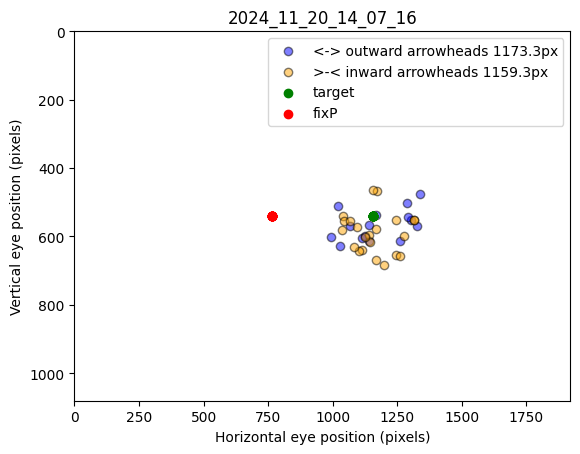

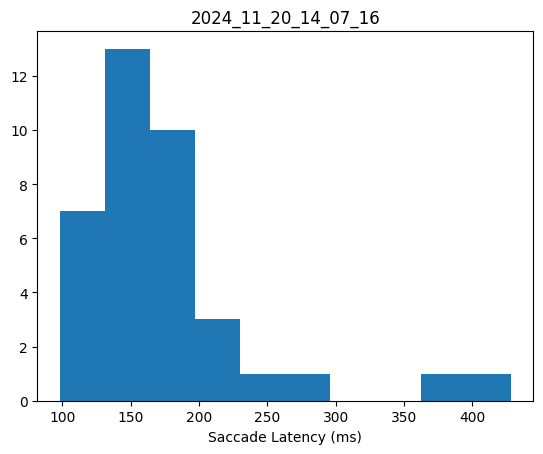

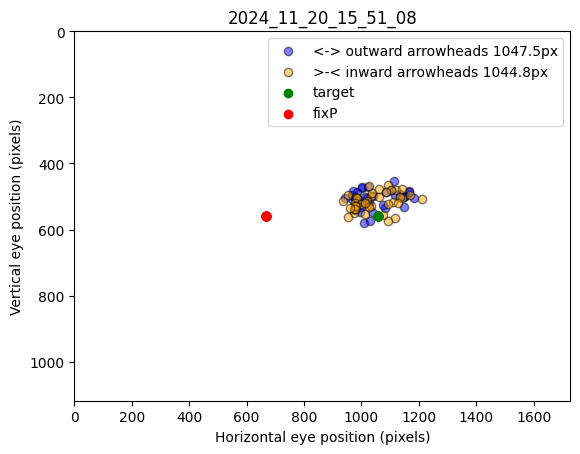

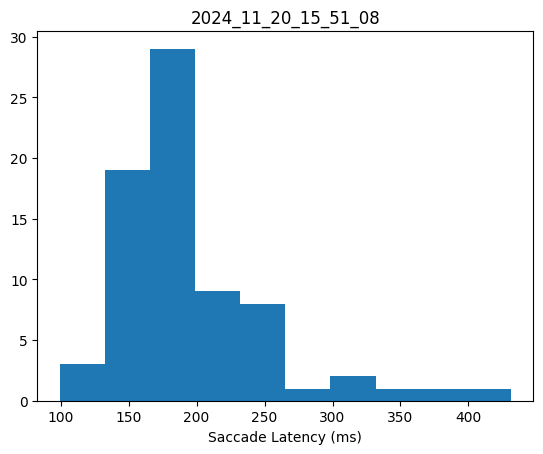

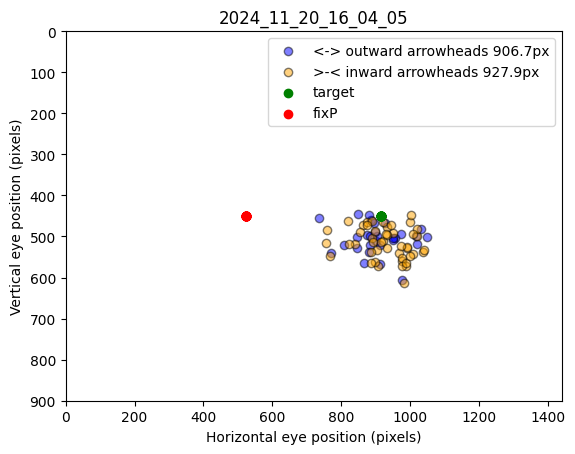

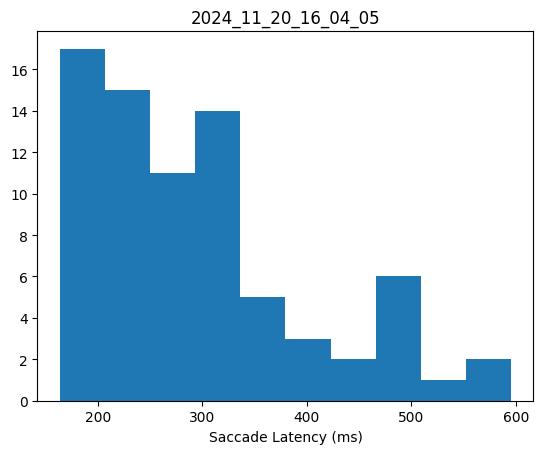

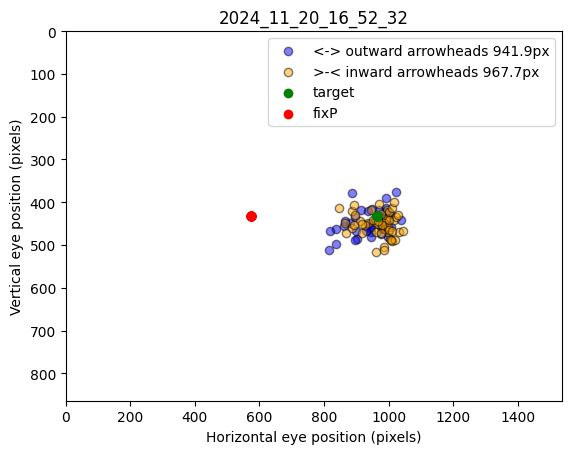

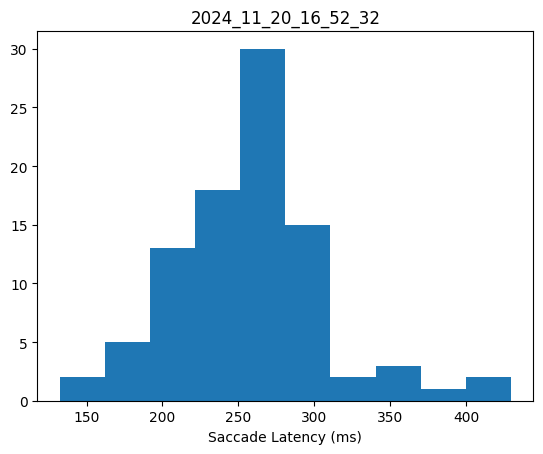

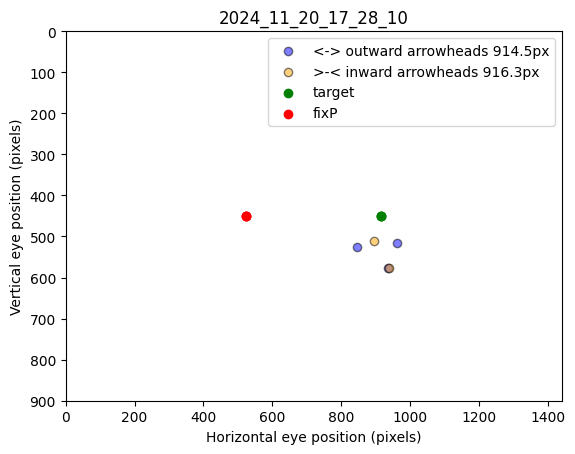

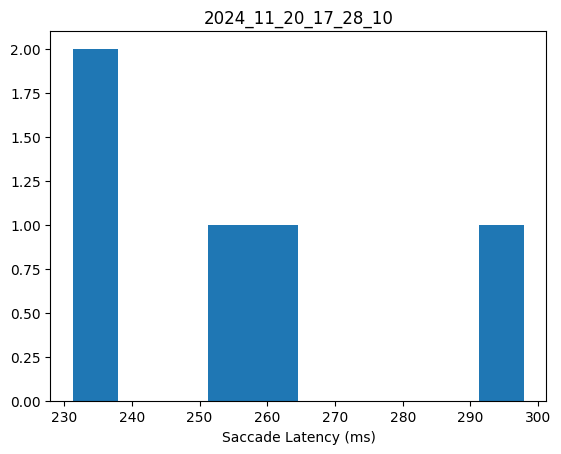

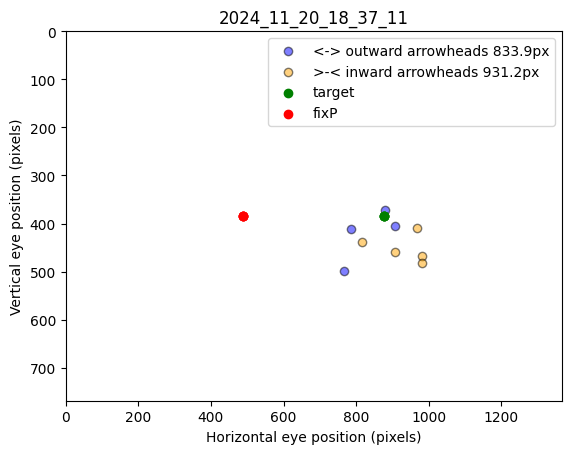

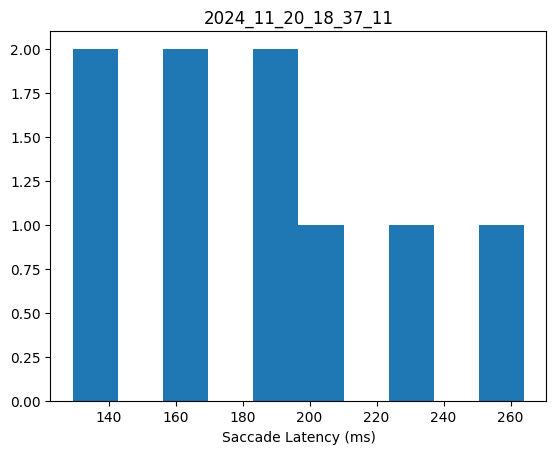

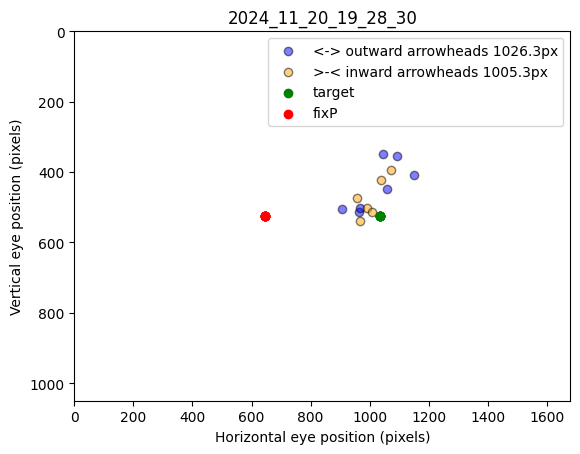

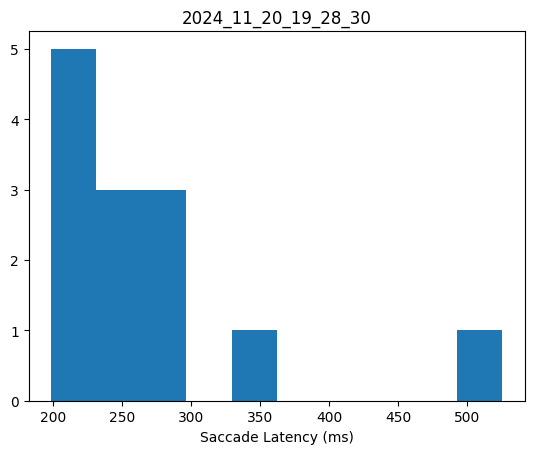

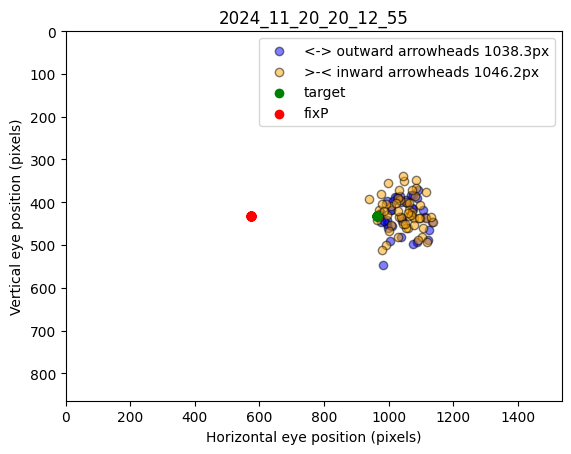

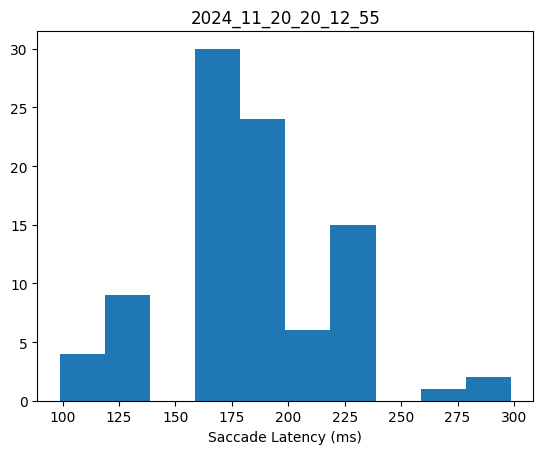

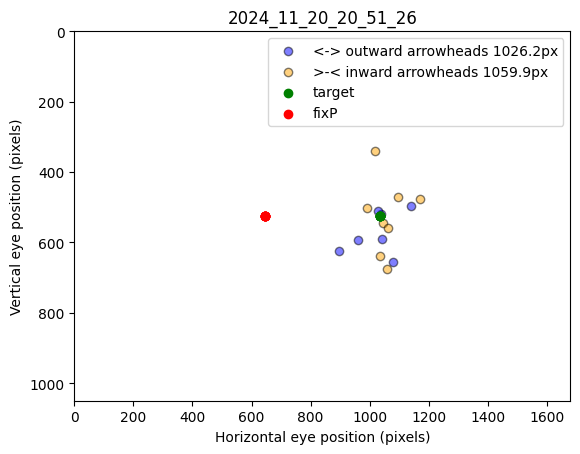

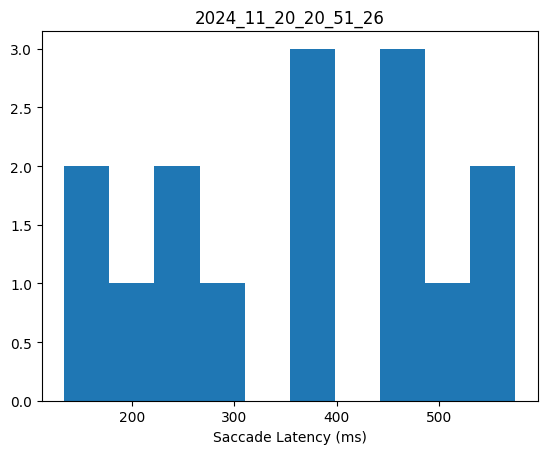

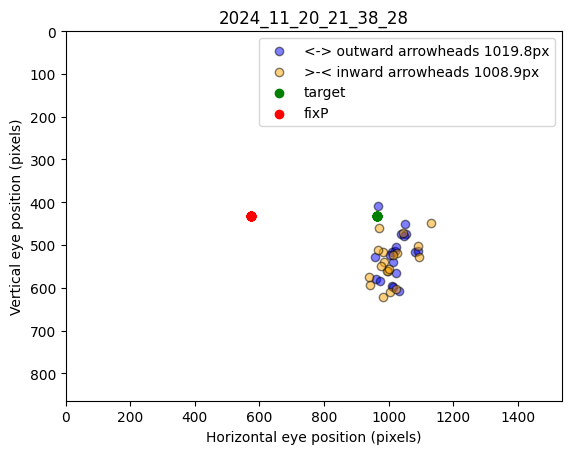

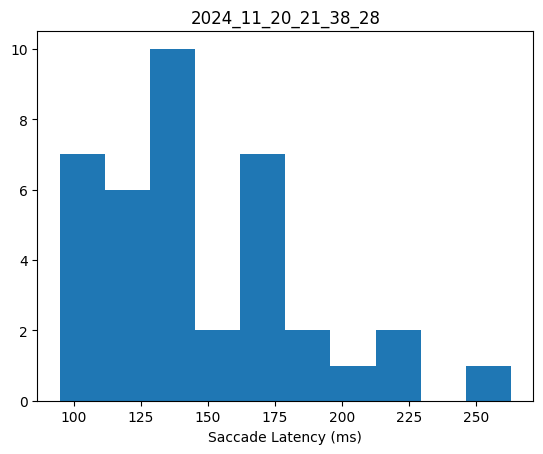

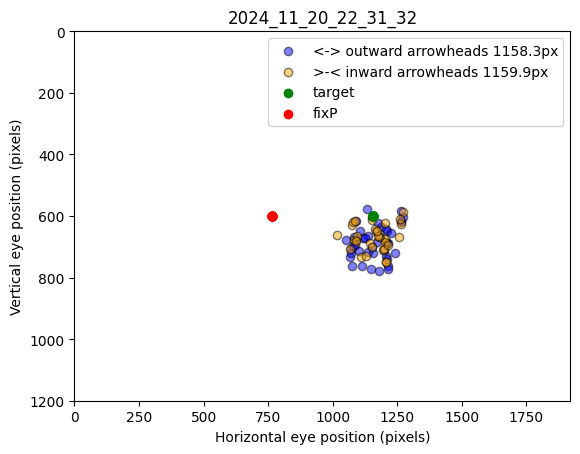

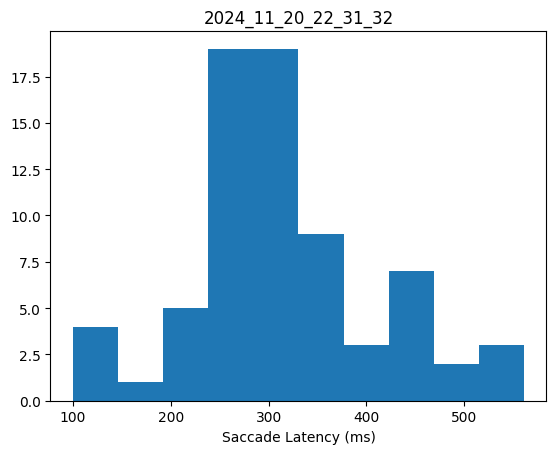

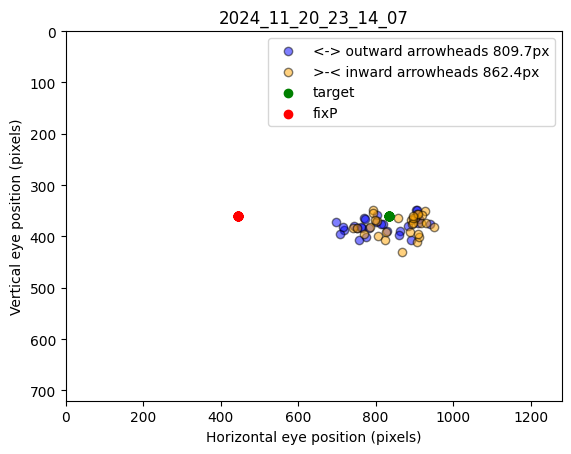

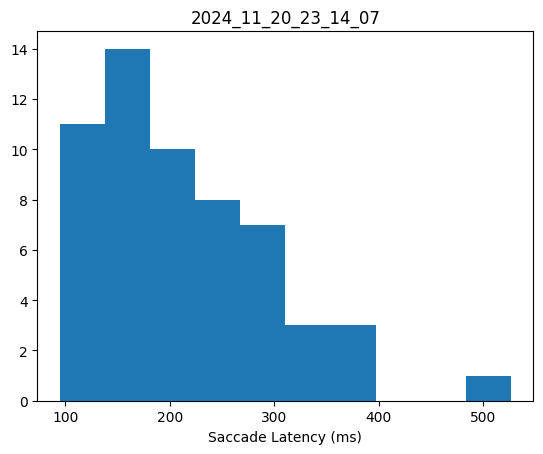

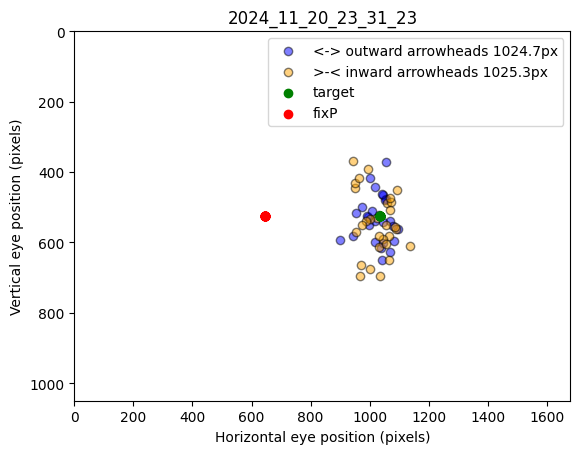

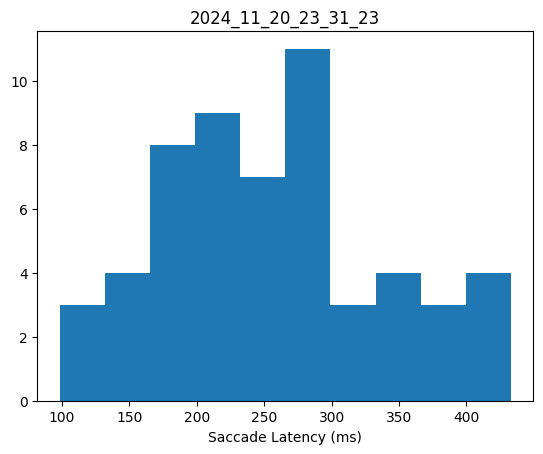

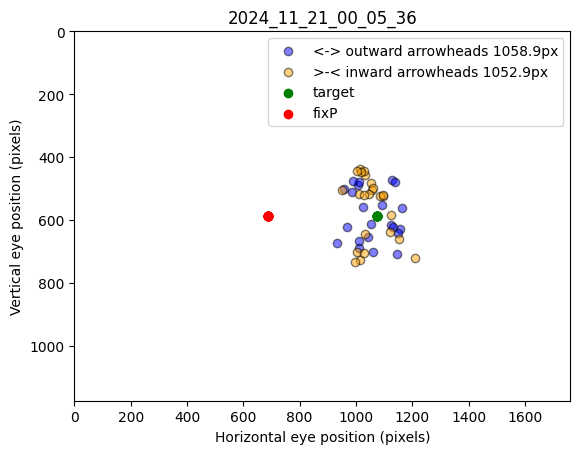

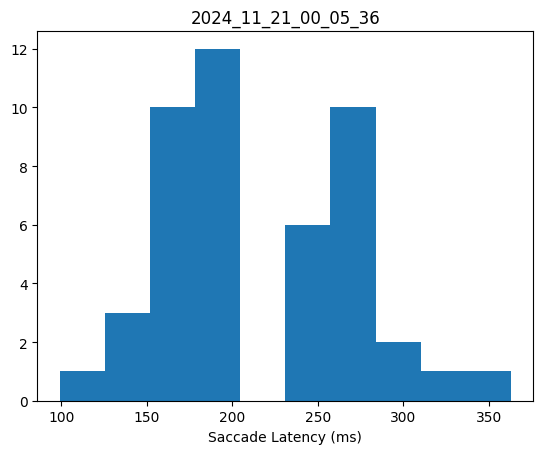

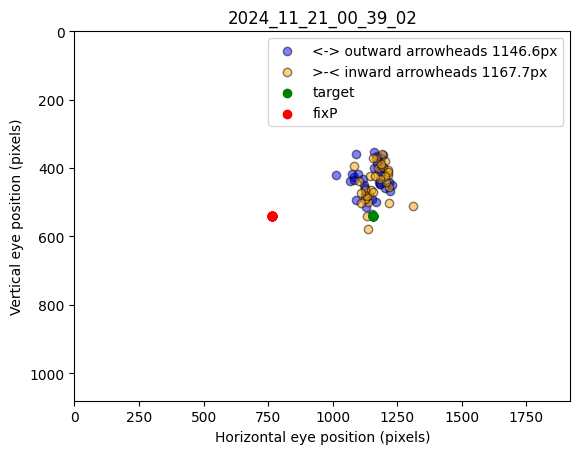

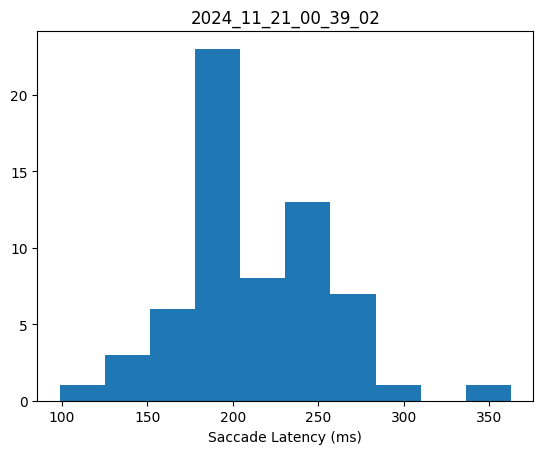

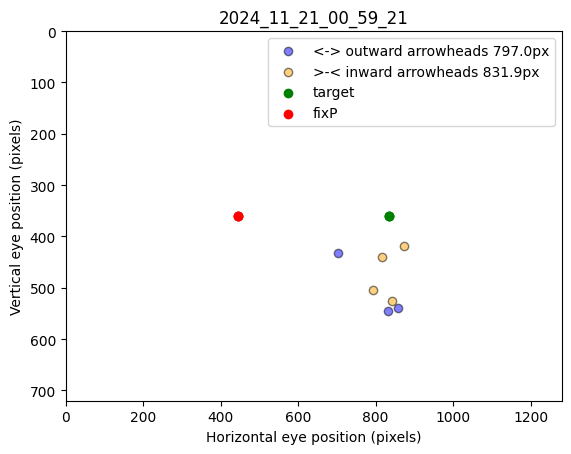

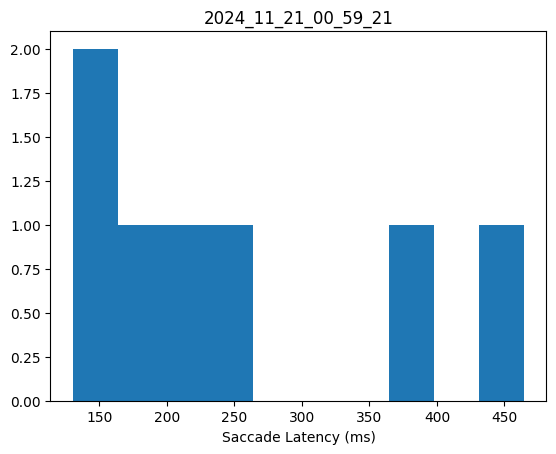

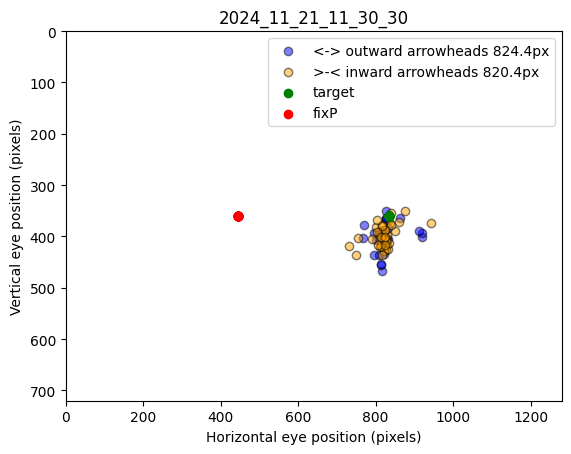

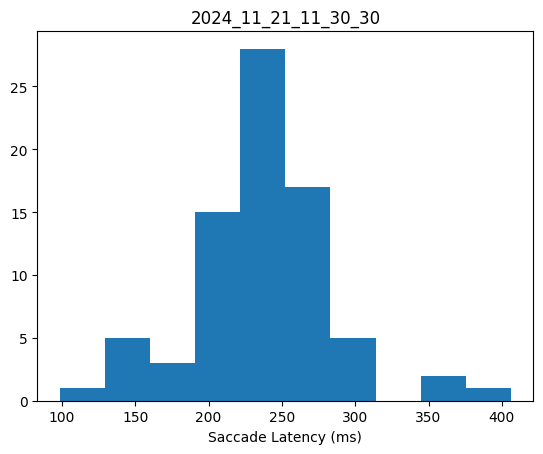

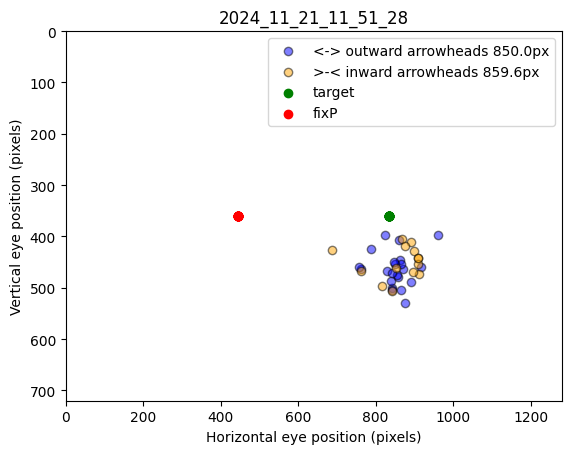

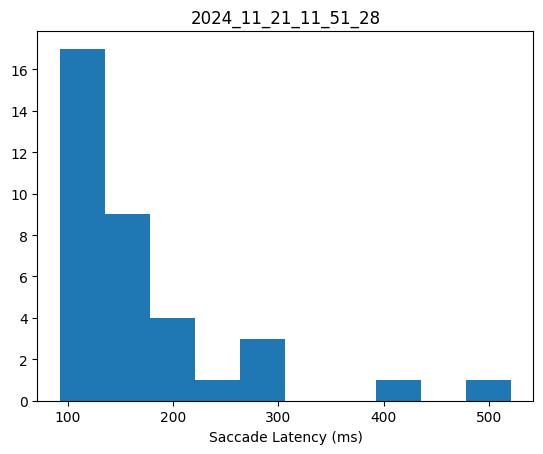

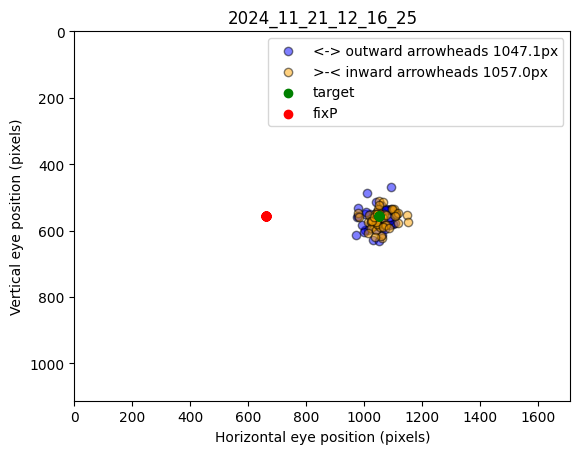

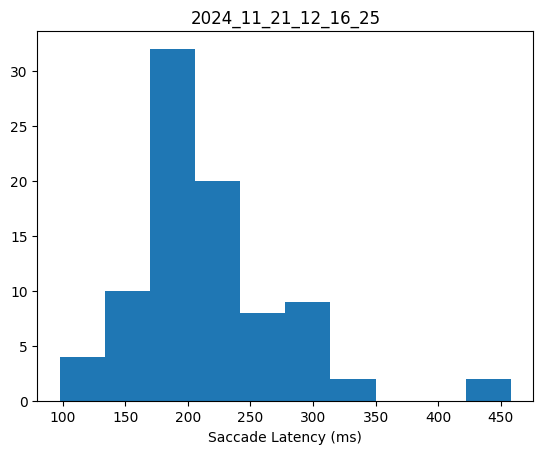

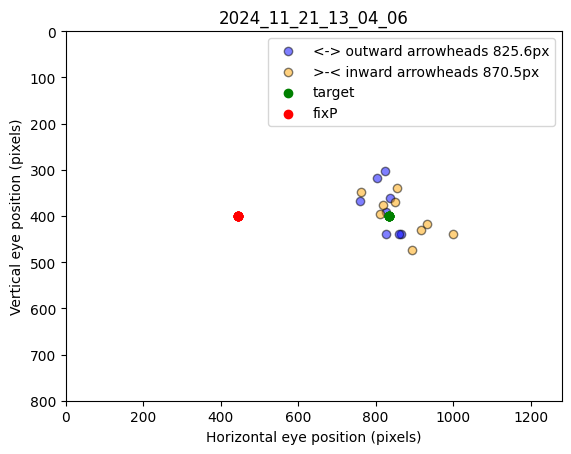

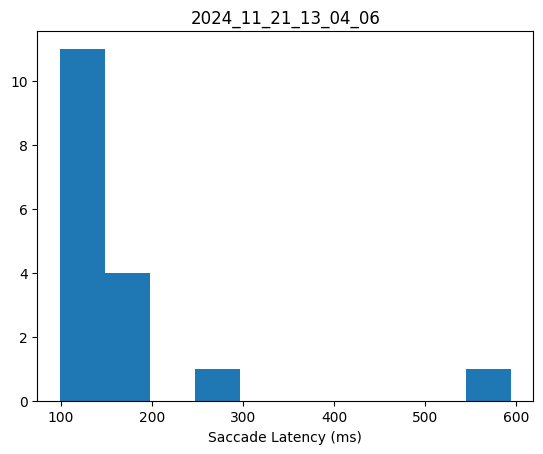

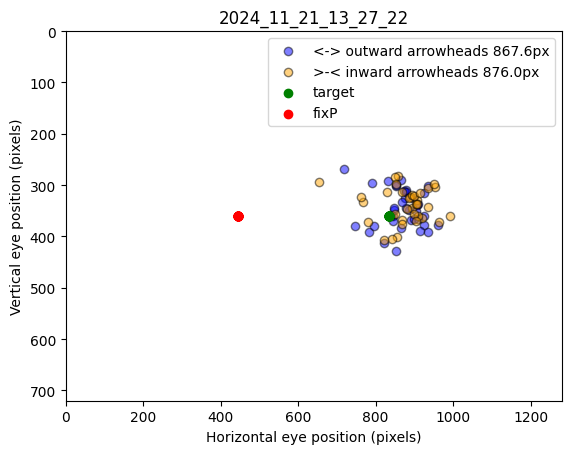

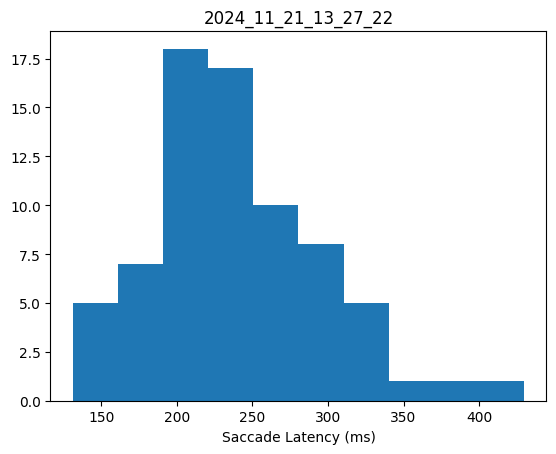

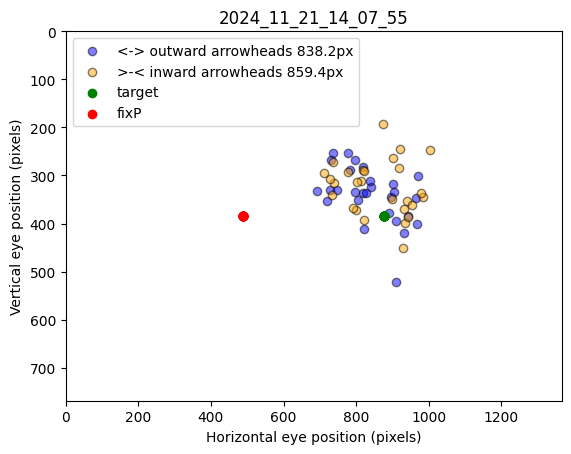

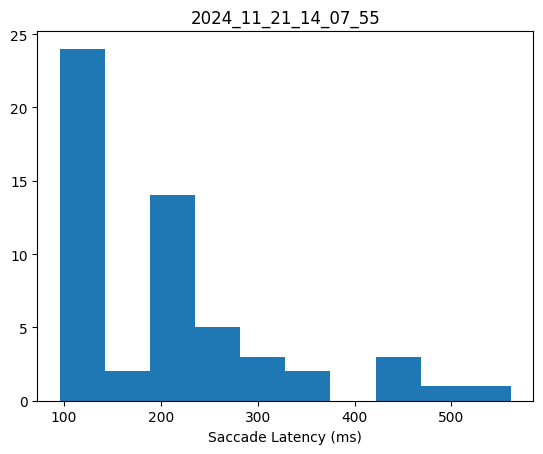

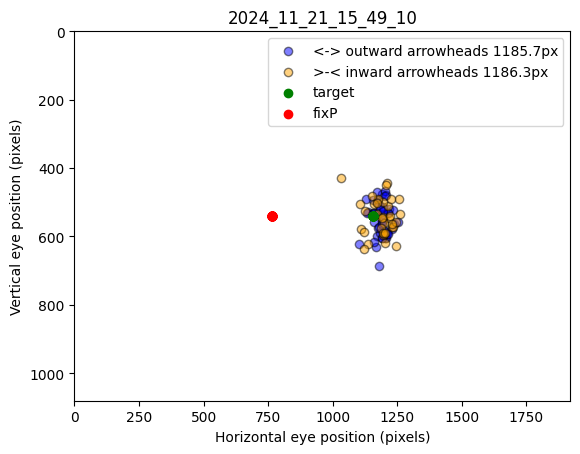

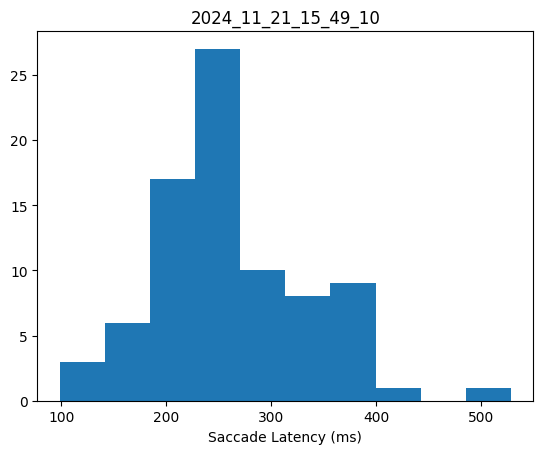

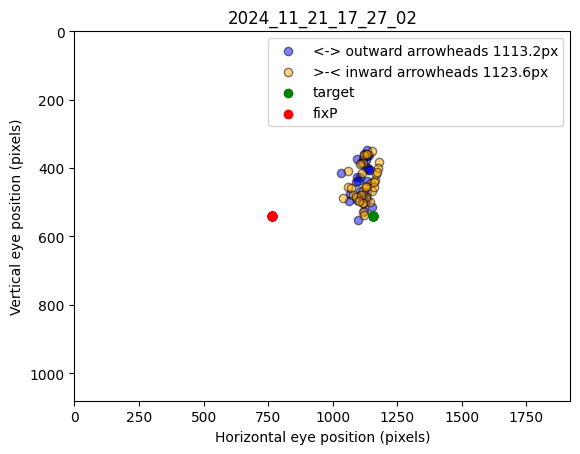

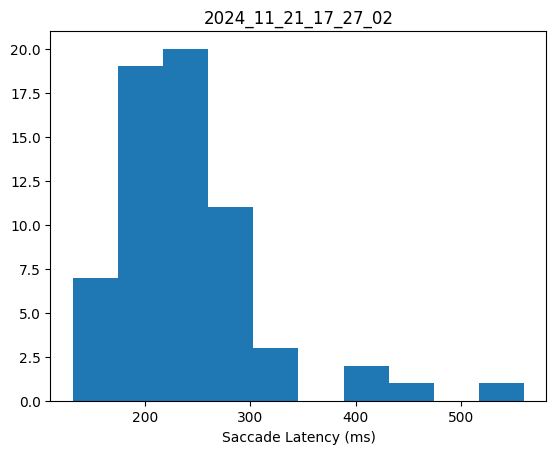

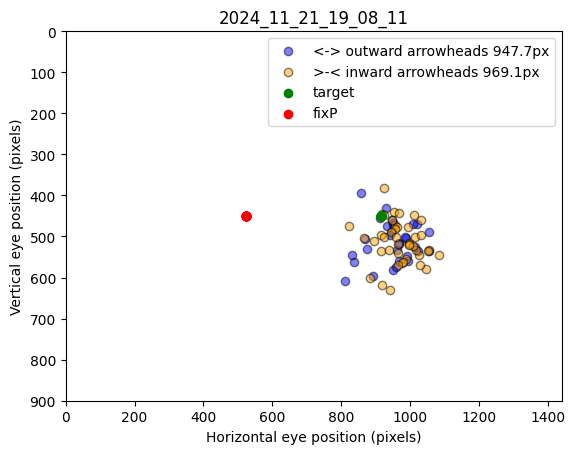

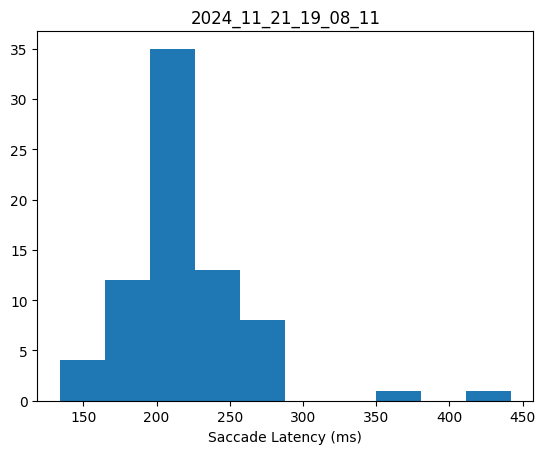

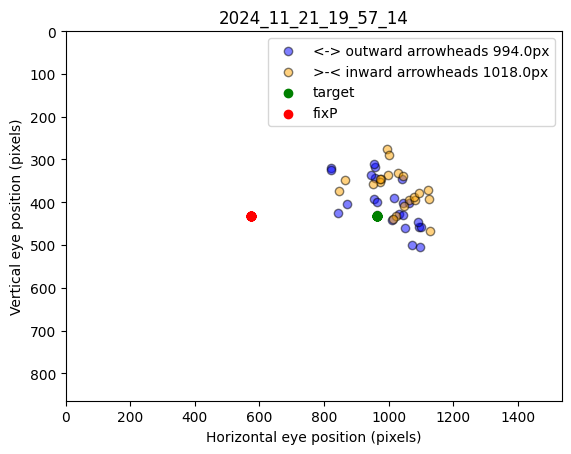

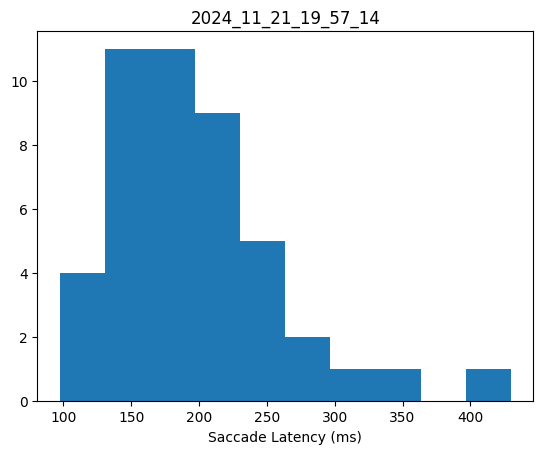

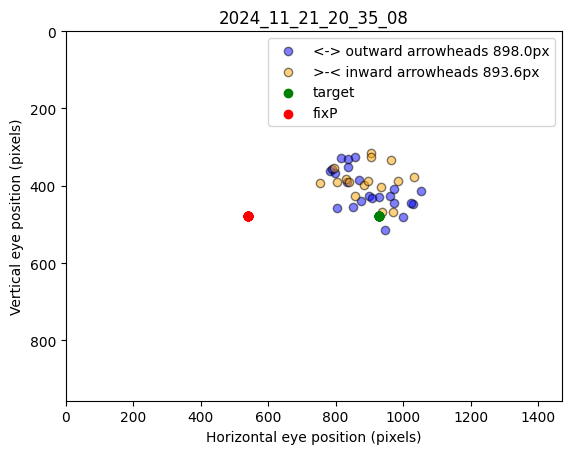

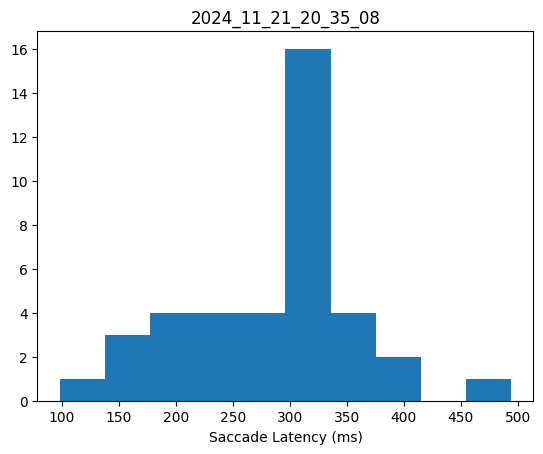

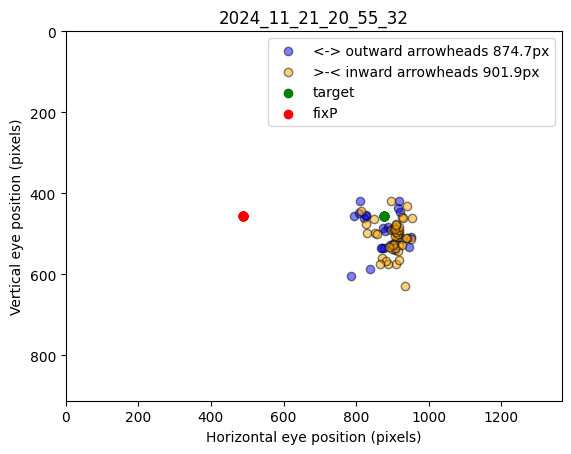

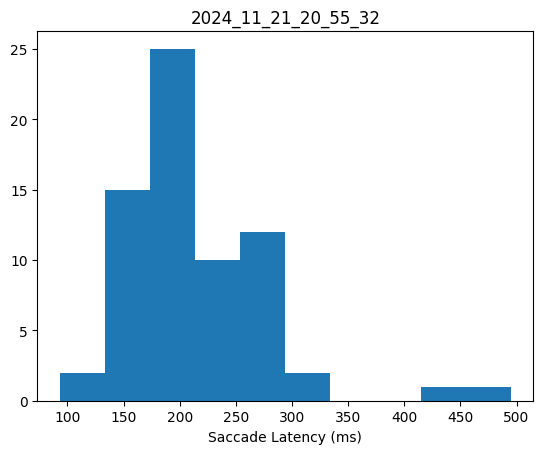

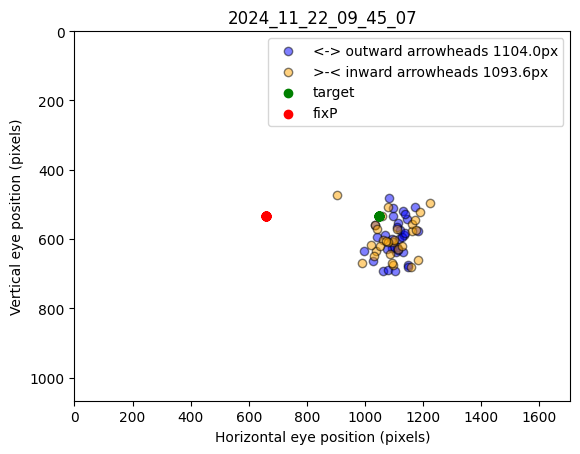

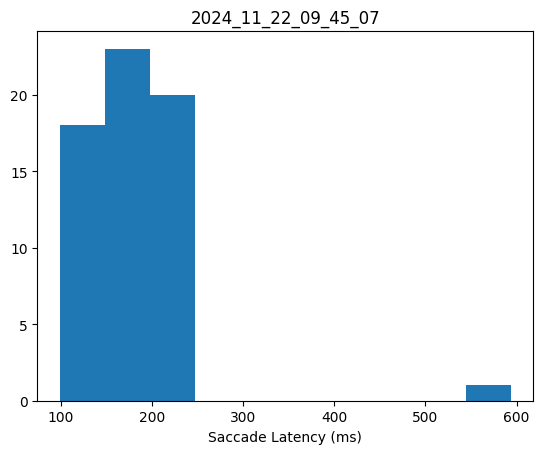

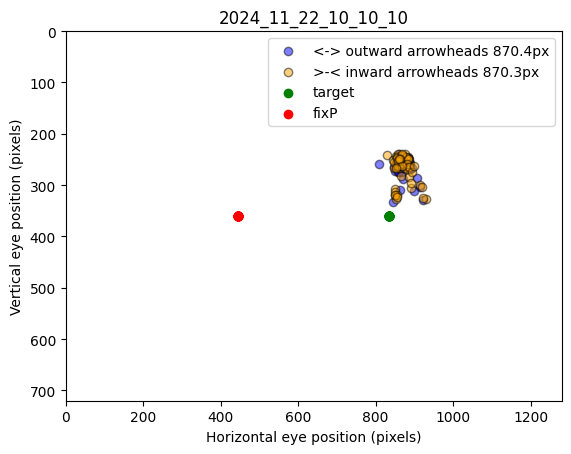

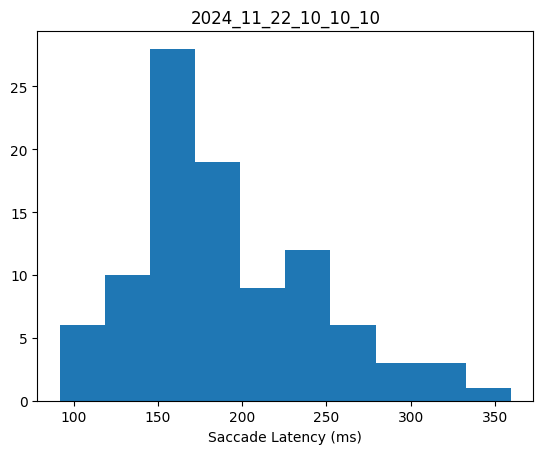

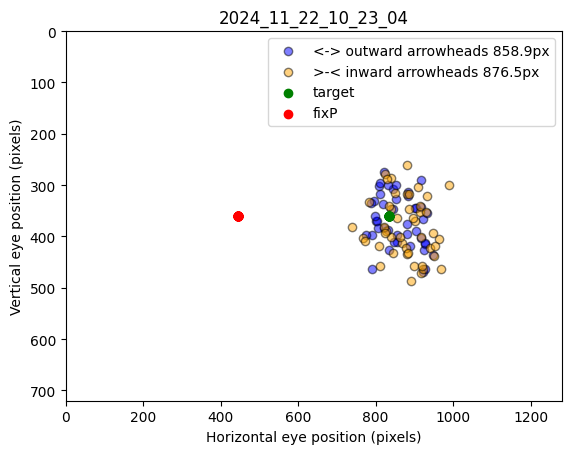

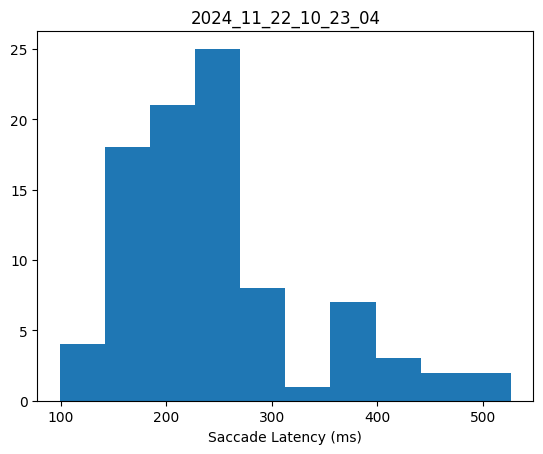

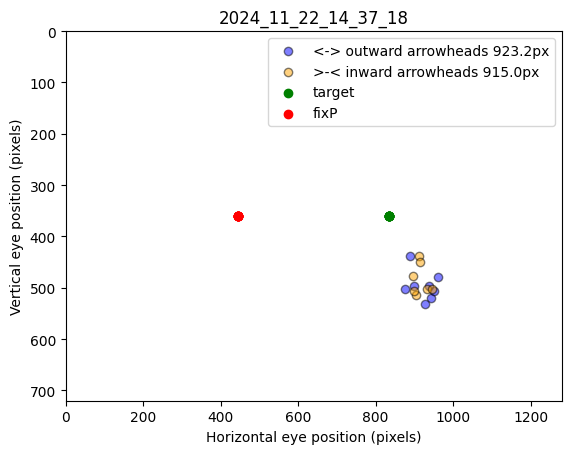

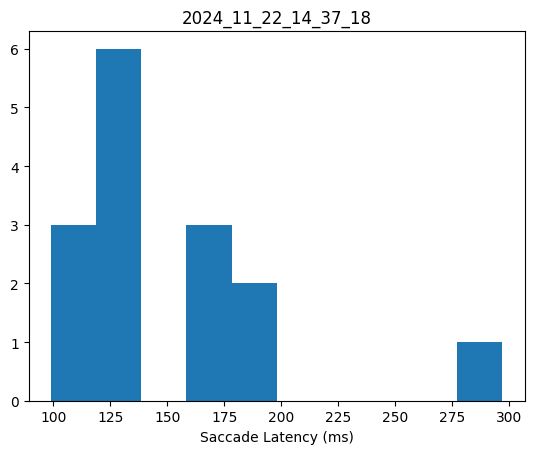

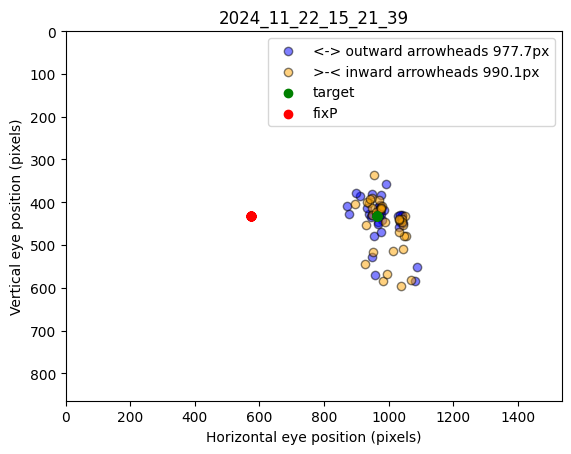

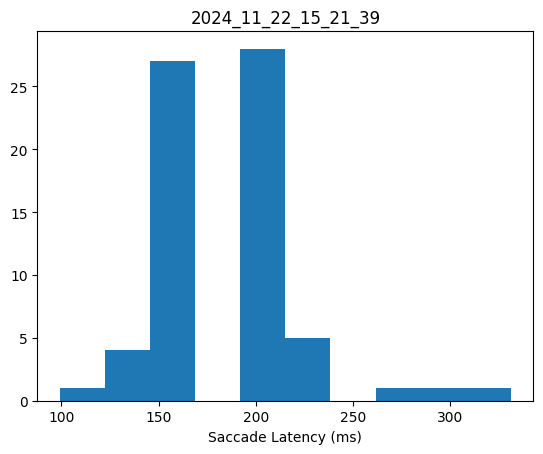

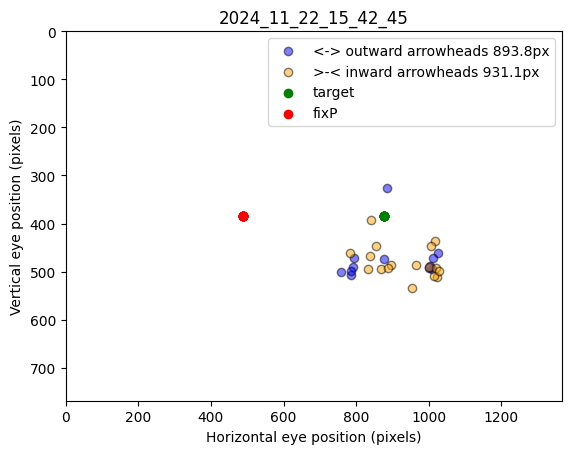

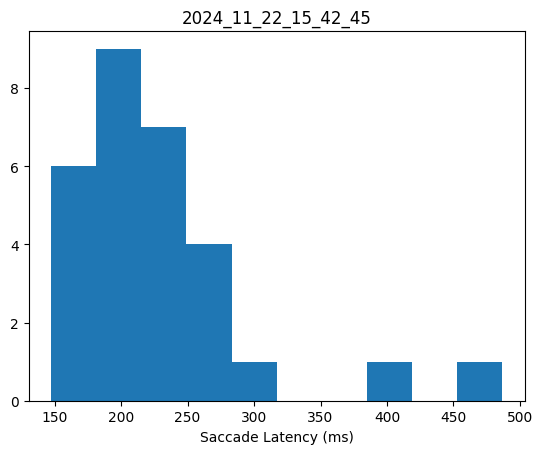

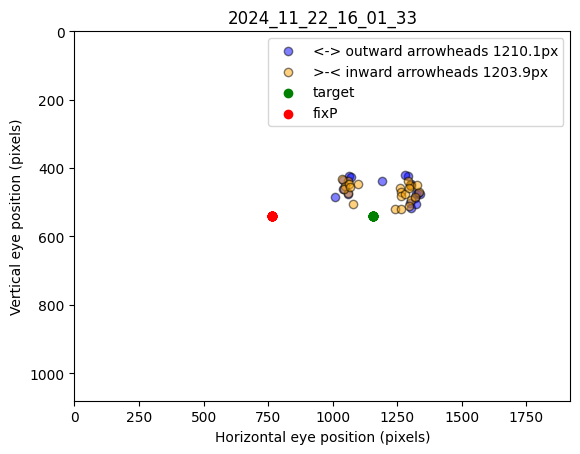

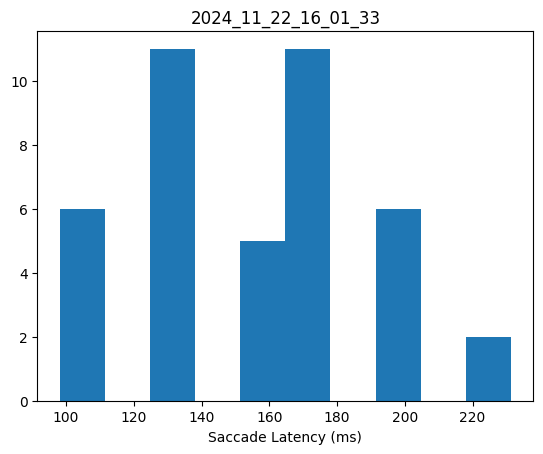

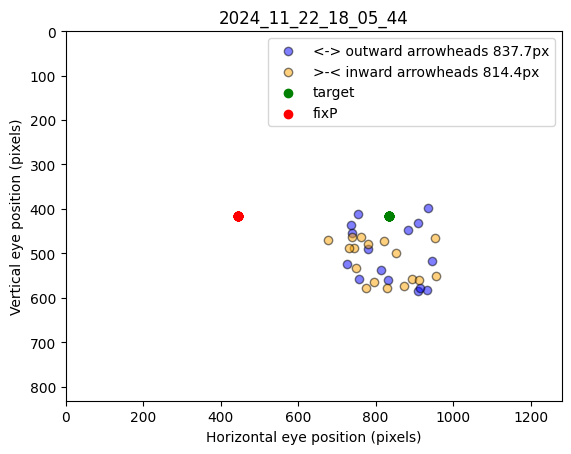

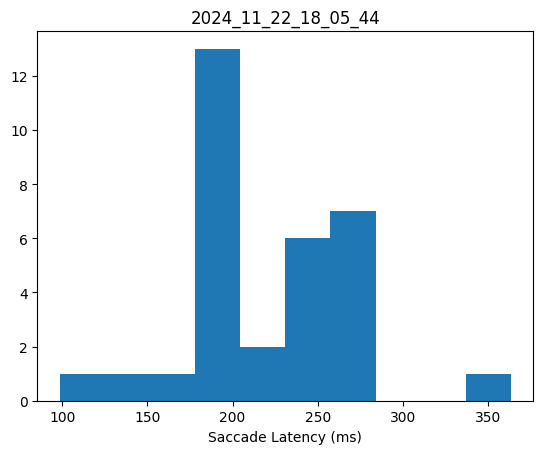

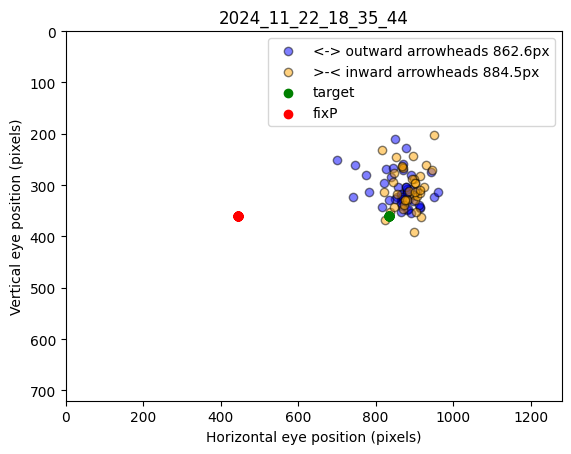

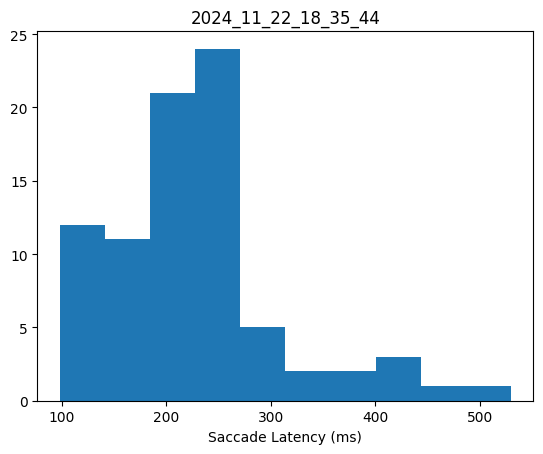

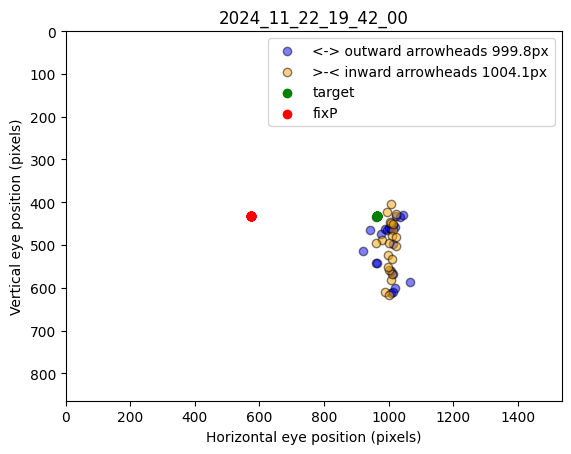

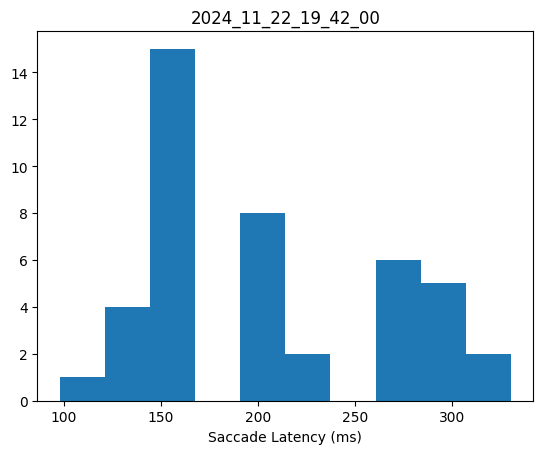

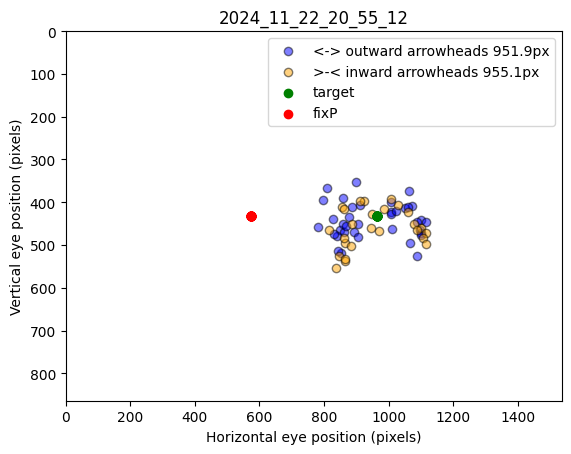

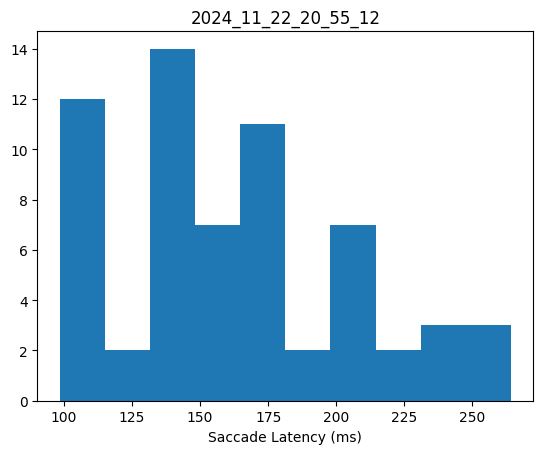

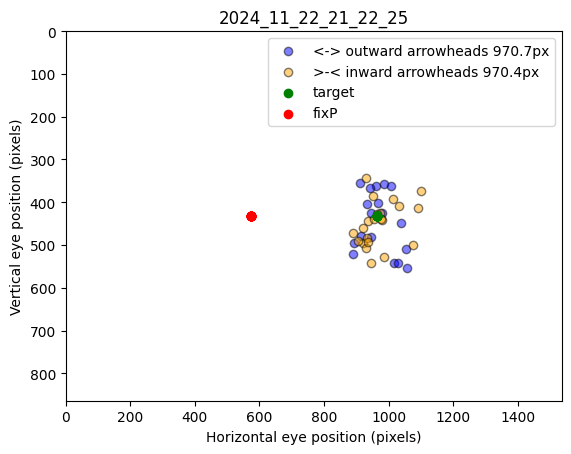

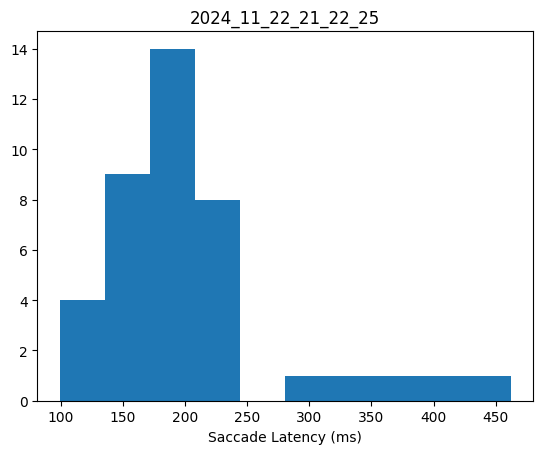

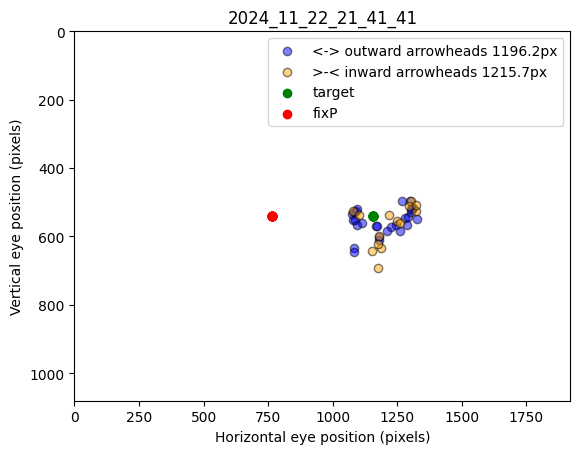

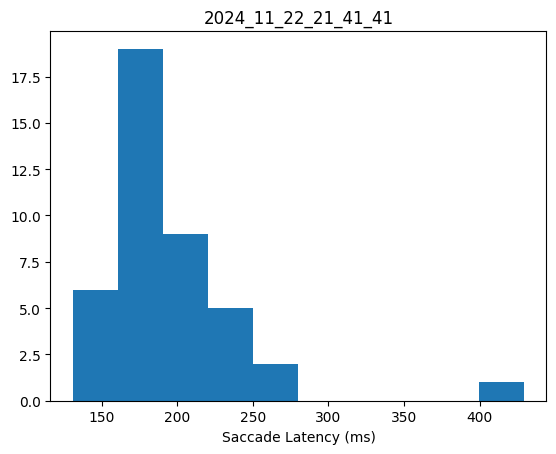

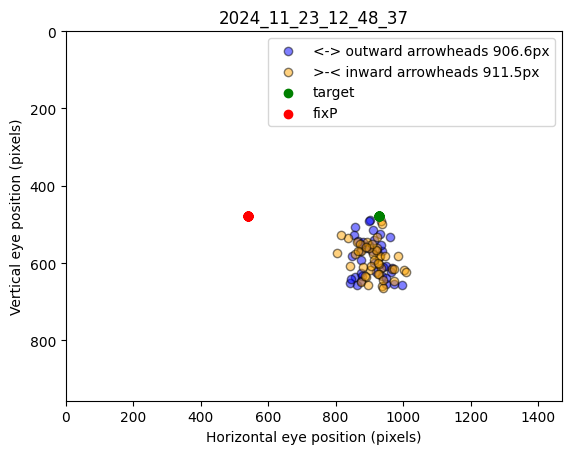

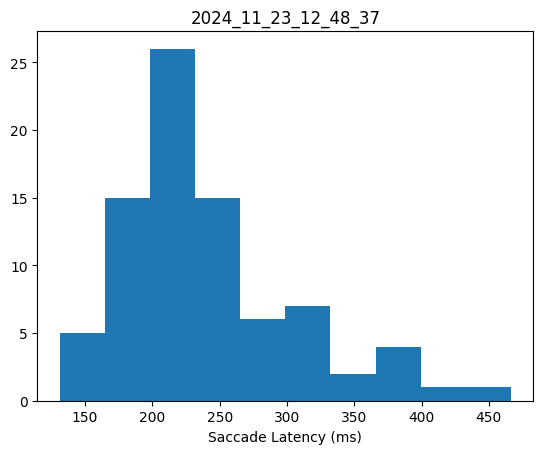

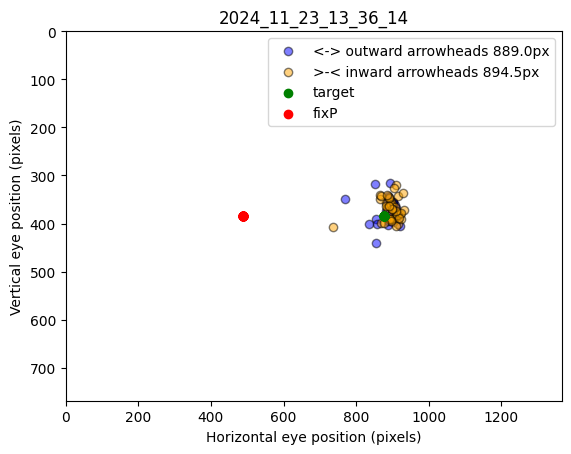

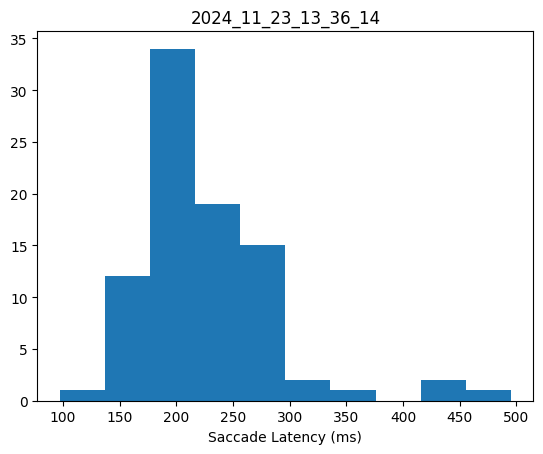

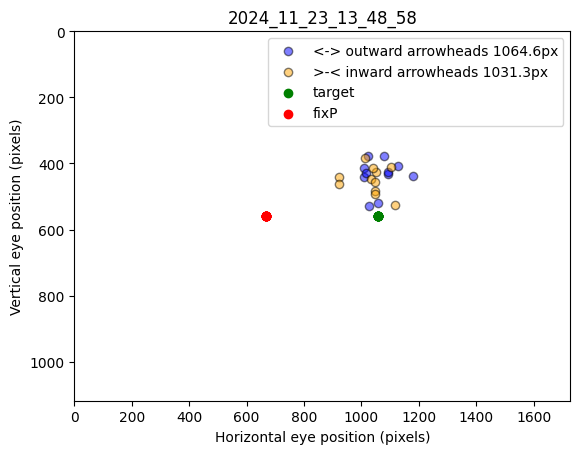

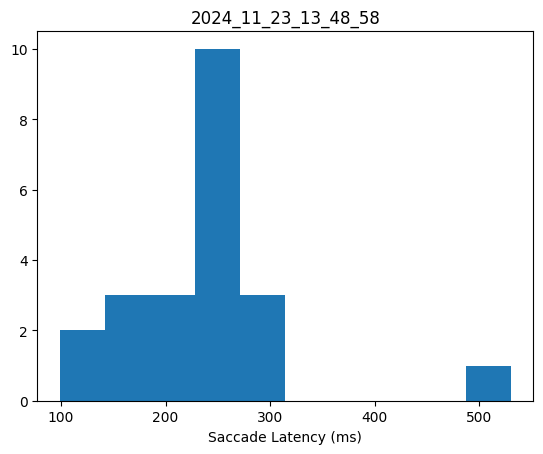

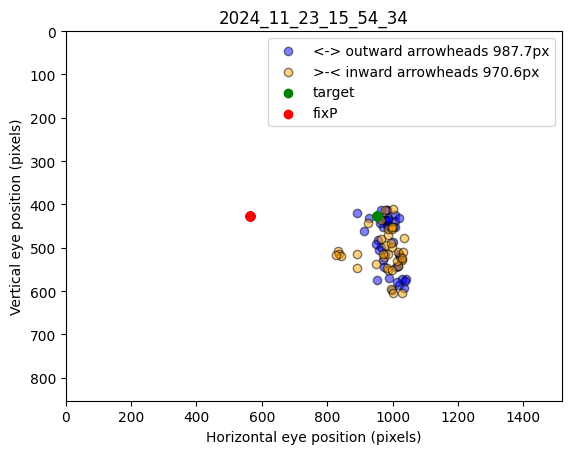

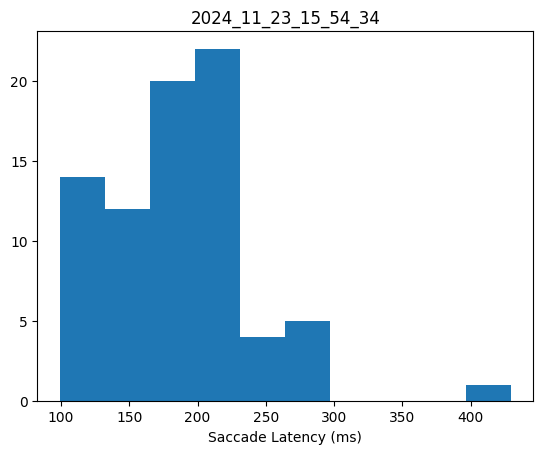

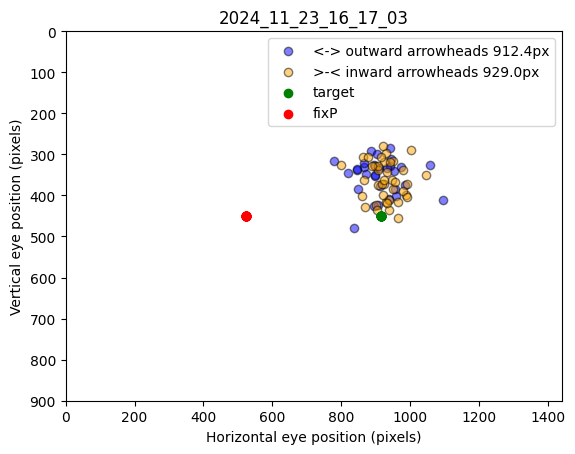

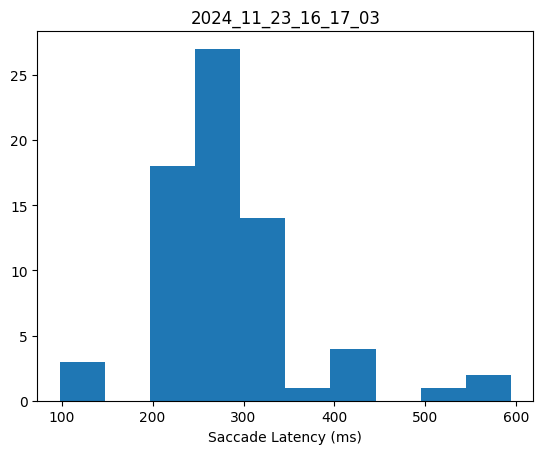

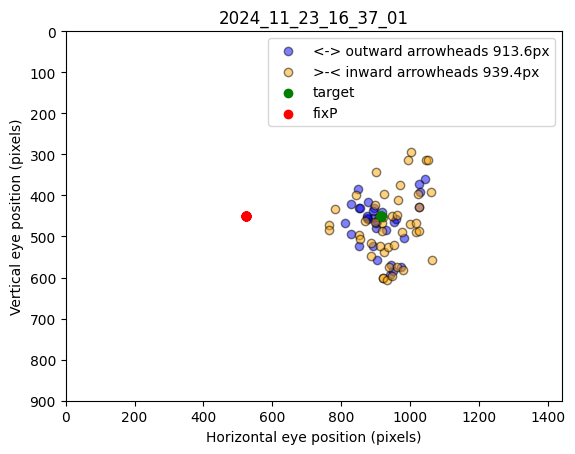

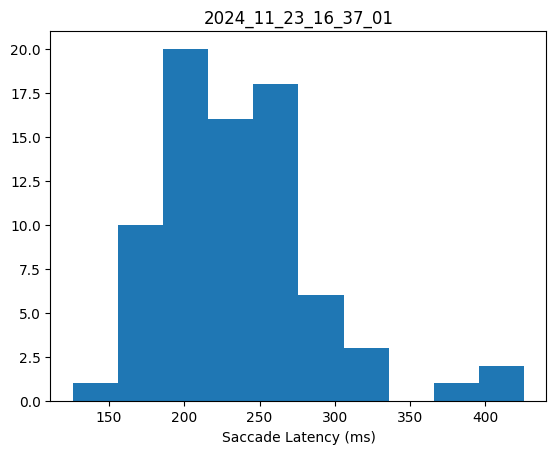

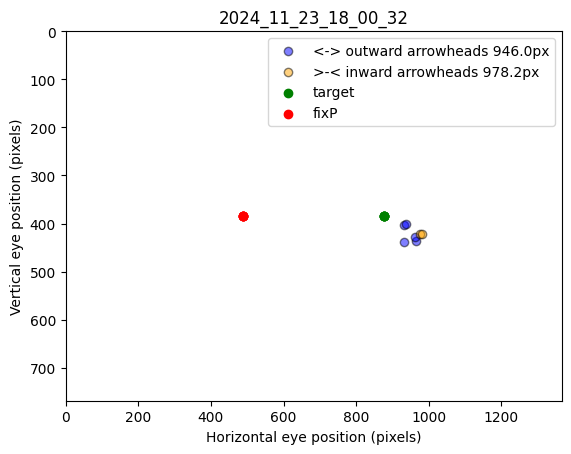

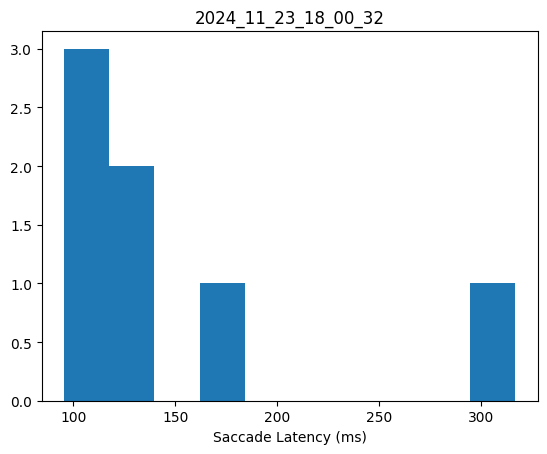

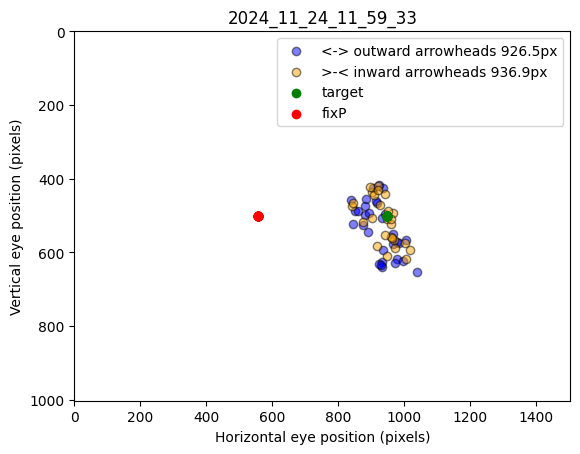

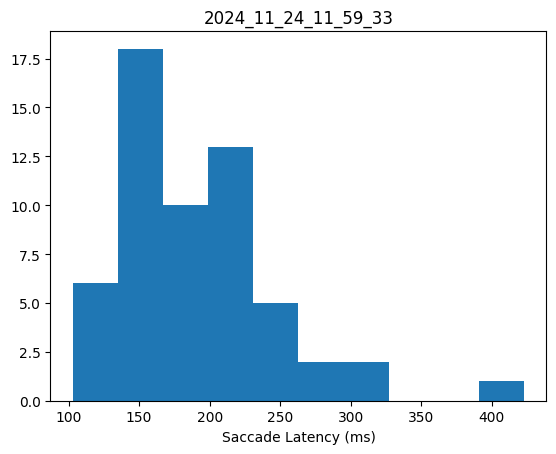

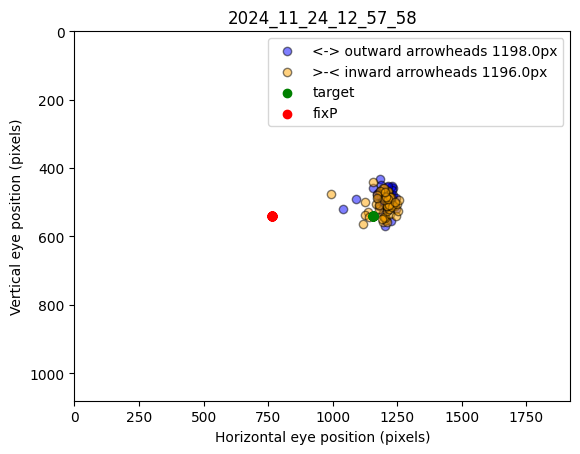

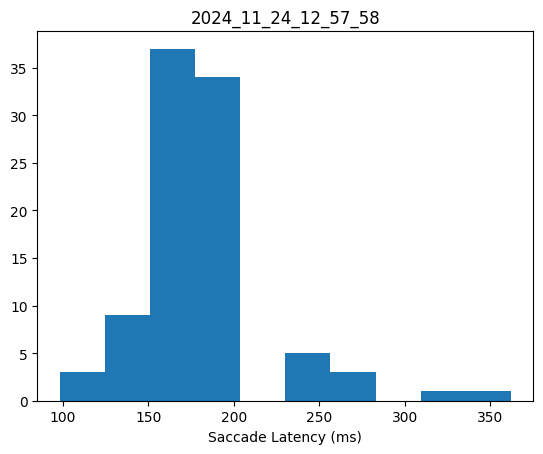

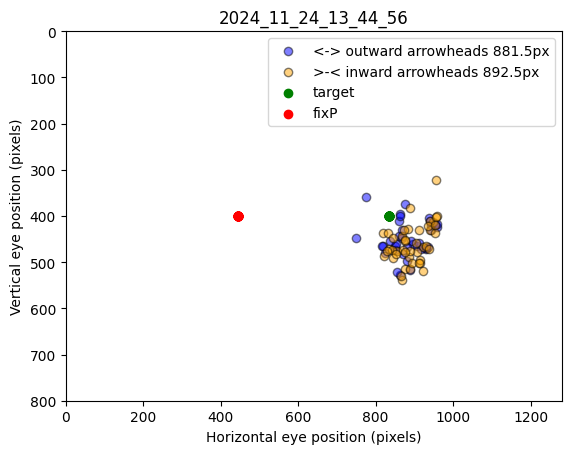

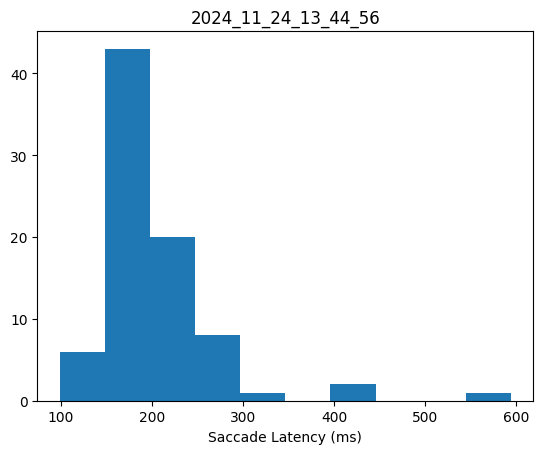

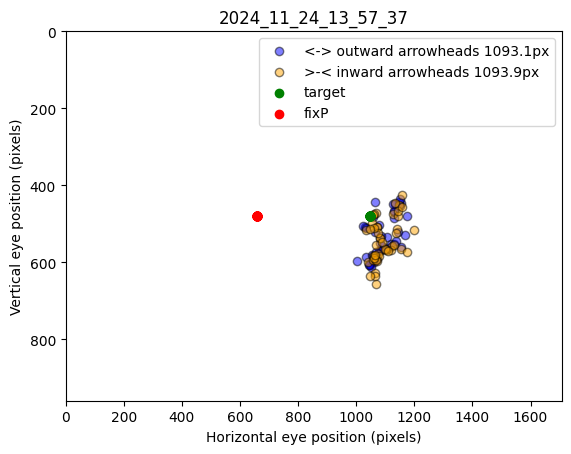

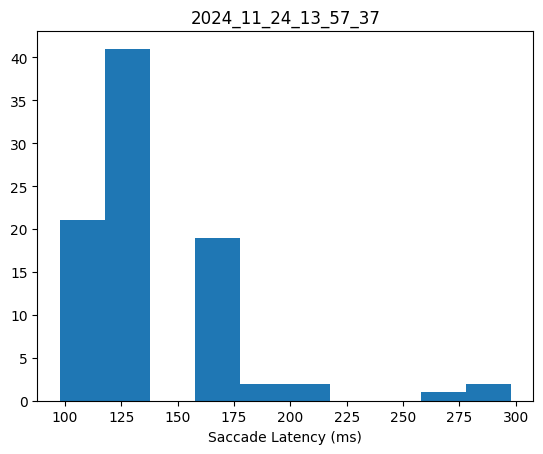

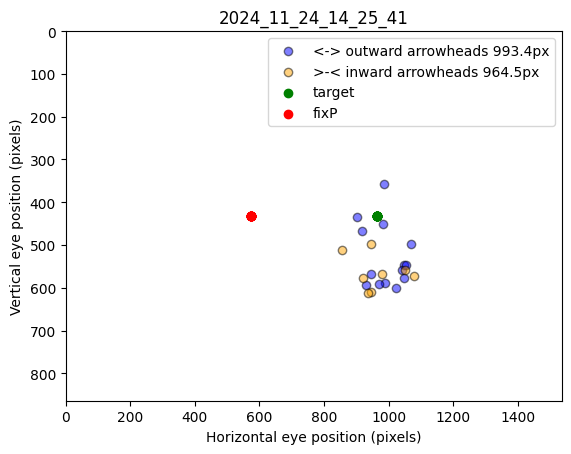

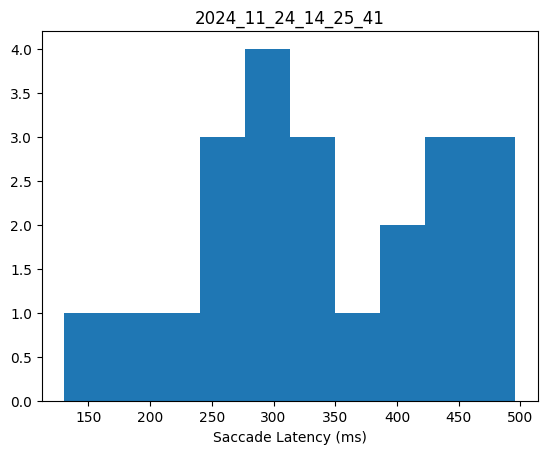

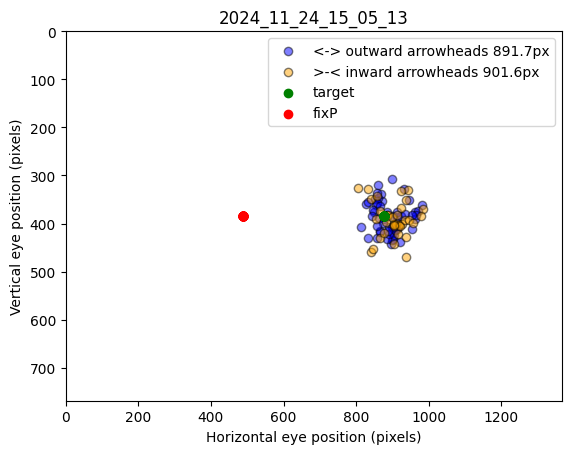

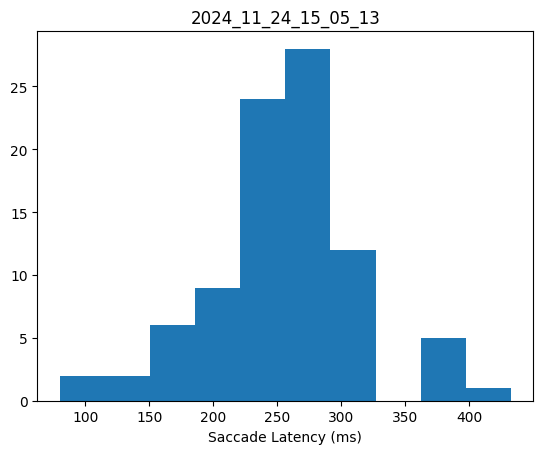

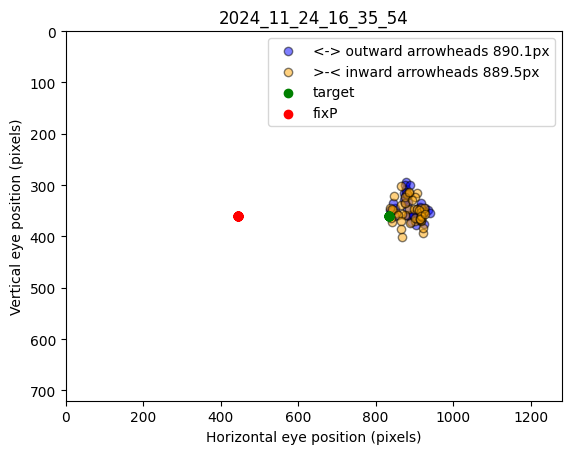

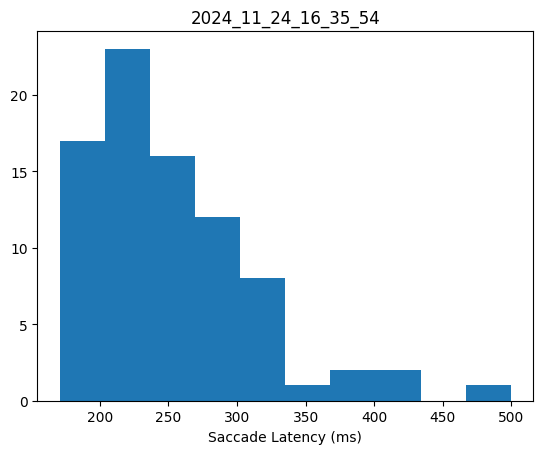

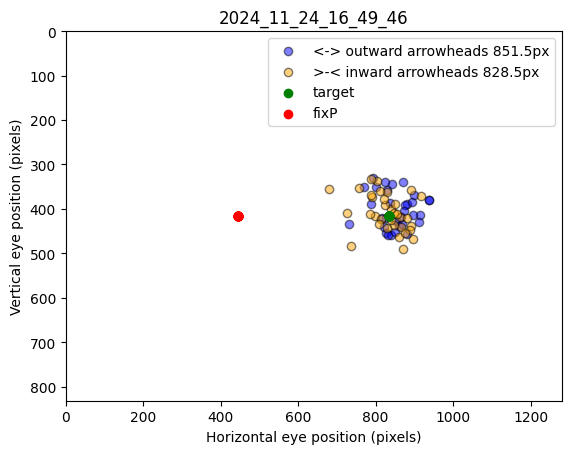

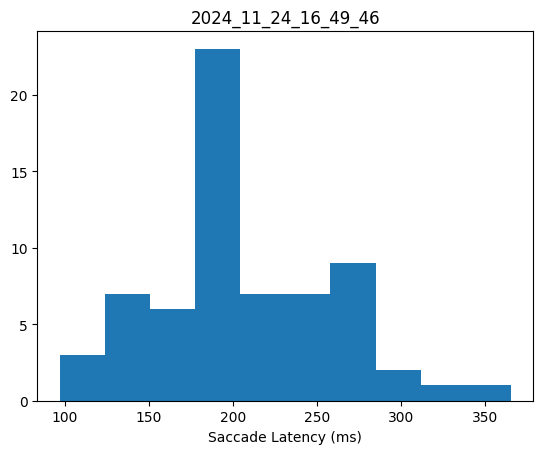

In [4]:
from deepeye_analysis_package.getFixations import extract_fixations

# Initialize an empty list to hold the processed dataframes
output_dfs = []
summary_dfs = []

# Get all folder names from the data directory
folder_names = [name for name in os.listdir(path_to_data) if os.path.isdir(os.path.join(path_to_data, name))]

# Process each participant's data
for fn in folder_names:
    # Check if _record_extra.csv exists, if not use _record.csv
    path_to_file = os.path.join(path_to_data, fn, f'{fn}_record_extra.csv')
    if not os.path.exists(path_to_file):
        path_to_file = os.path.join(path_to_data, fn, f'{fn}_record.csv')

        print(f'Extracting fixations for participant {fn}...')

        try:
            df = pd.read_csv(path_to_file, on_bad_lines='skip')
            df = extract_fixations(df, path_to_file)
            df = df.drop_duplicates(subset=['user_pred_px_x', 'user_pred_px_y'], ignore_index=True)  # Ensure unique coordinates (sometimes webcam is stuck)
            
        except FileNotFoundError:
            print(f'File does not exist: {path_to_file}')
            continue    
    else: 
        try:
            df = pd.read_csv(path_to_file, on_bad_lines='skip')
            df = df.drop_duplicates(subset=['user_pred_px_x', 'user_pred_px_y'], ignore_index=True)  # Ensure unique coordinates (sometimes webcam is stuck)

        except FileNotFoundError:
            print(f'File does not exist: {path_to_file}')
            continue

    print(f'Processing participant {fn}...')
    # Filter data to only include rows where the target was presented
    df1 = df[df['event'] == 'target_on'].copy()

    # Add subject ID to the dataframe
    df1['deepeye_id'] = fn

    ### Convert critical columns to numeric values if they are not ###
    df1['FixXPos'] = pd.to_numeric(df1['FixXPos'], errors='coerce')
    df1['FixYPos'] = pd.to_numeric(df1['FixYPos'], errors='coerce')
    df1['targetX'] = pd.to_numeric(df1['targetX'], errors='coerce')
    df1['fixationStimY'] = pd.to_numeric(df1['fixationStimY'], errors='coerce')
    df1['fixationStimX'] = pd.to_numeric(df1['fixationStimX'], errors='coerce')
    df1['resX'] = pd.to_numeric(df1['resX'], errors='coerce')
    df1['resY'] = pd.to_numeric(df1['resY'], errors='coerce')
    df1['scrW_cm'] = pd.to_numeric(df1['scrW_cm'], errors='coerce')
    df1['PrevFixXPos'] = pd.to_numeric(df1['PrevFixXPos'], errors='coerce')
    df1['PrevFixYPos'] = pd.to_numeric(df1['PrevFixYPos'], errors='coerce')
    df1['PrevFixSampTime'] = pd.to_numeric(df1['PrevFixSampTime'], errors='coerce')
    df1['DistFromPrevFix'] = pd.to_numeric(df1['DistFromPrevFix'], errors='coerce')

    # Get saccade endpoint data and latency
    summary_df = getSaccades(df1, fn, plot=True)  
    summary_dfs.append(summary_df)  

    # Accumulate the processed dataframe for this participant
    output_dfs.append(df1)

# Concatenate all participants' data into one DataFrame
if output_dfs:
    output_df = pd.concat(output_dfs, ignore_index=True)
    output_file = os.path.join(path_to_analysis, 'allSubjects_ML.csv')
    output_df.to_csv(output_file, index=False)
    print(f'Combined data saved to {output_file}')
else:
    print('No data was processed.')

# Concatenate all participants' summary data into one DataFrame
if summary_dfs:
    summary_df = pd.concat(summary_dfs, ignore_index=True)
    summary_file = os.path.join(path_to_analysis, 'allSubjects_ML_summary.csv')
    summary_df.to_csv(summary_file, index=False)
    print(f'Combined summary data saved to {summary_file}')
else:
    print('No summary data was processed.')


### Filter out subjects with too few datapoints in outward or inward condition

In [5]:
# Count the number of data points per 'deepeye_id' and 'condition'
count_df = summary_df.groupby(['condition', 'deepeye_id']).size().reset_index(name='counts')
print(count_df)

# Set a threshold for the minimum number of data points per condition
min_data_points = 5  # Adjust this threshold as needed

# Filter out deepeye_ids that don't meet the minimum number of data points
invalid_deepeye_ids = count_df[count_df['counts'] <= min_data_points]['deepeye_id'].unique()

print(f'\nExcluded subjects based on too few valid trials: {invalid_deepeye_ids}')

# Filter the original DataFrame to exclude the invalid deepeye_ids
filtered_summary_df = summary_df[~summary_df['deepeye_id'].isin(invalid_deepeye_ids)]

             condition           deepeye_id  counts
0     arrowHeadsInward  2024_11_20_14_07_16      22
1     arrowHeadsInward  2024_11_20_15_51_08      39
2     arrowHeadsInward  2024_11_20_16_04_05      47
3     arrowHeadsInward  2024_11_20_16_52_32      50
4     arrowHeadsInward  2024_11_20_17_28_10       2
..                 ...                  ...     ...
109  arrowHeadsOutward  2024_11_24_14_25_41      14
110  arrowHeadsOutward  2024_11_24_15_05_13      54
111  arrowHeadsOutward  2024_11_24_16_11_14       2
112  arrowHeadsOutward  2024_11_24_16_35_54      37
113  arrowHeadsOutward  2024_11_24_16_49_46      32

[114 rows x 3 columns]

Excluded subjects based on too few valid trials: ['2024_11_20_17_28_10' '2024_11_20_18_37_11' '2024_11_21_00_59_21'
 '2024_11_23_18_00_32' '2024_11_23_14_18_09' '2024_11_24_16_11_14']


### Analyze Illusion Size Per Participant

condition           deepeye_id  arrowHeadsInward  arrowHeadsOutward  \
0          2024_11_20_14_07_16       1159.288569        1173.315830   
1          2024_11_20_15_51_08       1044.780331        1047.545845   
2          2024_11_20_16_04_05        927.916777         906.669451   
3          2024_11_20_16_52_32        967.667329         941.872673   
4          2024_11_20_19_28_30       1005.320599        1026.272697   
5          2024_11_20_20_12_55       1046.176103        1038.308565   
6          2024_11_20_20_51_26       1059.893662        1026.234122   
7          2024_11_20_21_38_28       1008.895197        1019.780867   
8          2024_11_20_22_31_32       1159.864630        1158.336552   
9          2024_11_20_23_14_07        862.389478         809.667956   
10         2024_11_20_23_31_23       1025.319035        1024.717778   
11         2024_11_21_00_05_36       1052.932629        1058.922928   
12         2024_11_21_00_39_02       1167.680748        1146.613298   
13    

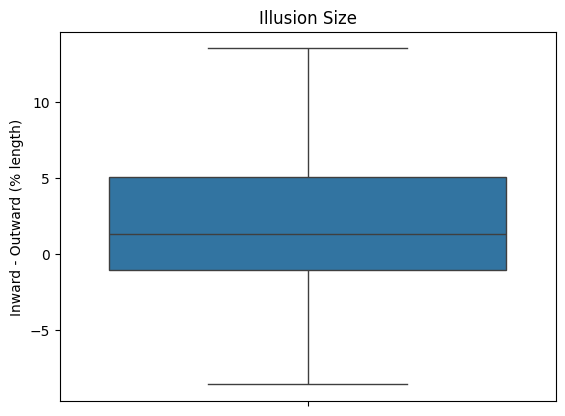

In [6]:
# Summary statistics for the saccade endpoints
illusSize_df = filtered_summary_df.groupby(['condition', 'deepeye_id', 'pp_id',
                                        'scale_px_per_cm', 'line_length_cm',
                                        'NormtargetX', 'NormfixationStimX',
                                        'fixationStimY'])[['NormFixXPos', 'FixYPos']].mean().reset_index()
# print(illusSize_df)
# Extract constant per participant
df_a = filtered_summary_df.groupby(['deepeye_id', 'scale_px_per_cm',
                                    'line_length_cm', 'NormtargetX',
                                    'NormfixationStimX','fixationStimY'])[['NormFixXPos']].mean().reset_index()
# print(df_a)
a = df_a.scale_px_per_cm
b = df_a.line_length_cm
# c = df_a.NormtargetX
# d = df_a.fixationStimY
# e = df_a.NormfixationStimX

# Pivot the DataFrame to have conditions as columns
illusSize_df_FixXPos = illusSize_df.pivot(index='deepeye_id', columns='condition', values='NormFixXPos').reset_index()
illusSize_df_FixXPos['IllusionSize'] = illusSize_df_FixXPos.arrowHeadsInward - illusSize_df_FixXPos.arrowHeadsOutward
illusSize_df_FixXPos['IllusionSize_percent'] = illusSize_df_FixXPos['IllusionSize']/a / b * 100.0

# Drop subjects with NaN values
illusSize_df_FixXPos = illusSize_df_FixXPos.dropna()
print(illusSize_df_FixXPos)

# Plot the illusion size
plt.figure()
plt.title('Illusion Size')
plt.ylabel('Inward - Outward (% length)')
sns.boxplot(illusSize_df_FixXPos.IllusionSize_percent)

# T-test
from scipy.stats import ttest_rel
t, p = ttest_rel(illusSize_df_FixXPos.arrowHeadsInward, illusSize_df_FixXPos.arrowHeadsOutward)
print(f'T-test: t={t}, p={p}')

print(f'Mean Illusion_%: {illusSize_df_FixXPos.IllusionSize_percent.mean()}')
print(f'Mean line_length_cm: {b.mean()}')
print(f'Number of participants: {illusSize_df_FixXPos.shape[0]}')

### Analyze Saccade Latency per subject

condition           deepeye_id  arrowHeadsInward  arrowHeadsOutward  \
0          2024_11_20_14_07_16        154.527273         171.640000   
1          2024_11_20_15_51_08        199.261538         201.837143   
2          2024_11_20_16_04_05        300.029787         291.644828   
3          2024_11_20_16_52_32        252.932000         257.368293   
4          2024_11_20_19_28_30        265.000000         263.471429   
5          2024_11_20_20_12_55        192.450943         173.763158   
6          2024_11_20_20_51_26        433.750000         279.714286   
7          2024_11_20_21_38_28        136.831579         154.831579   
8          2024_11_20_22_31_32        322.006897         312.274419   
9          2024_11_20_23_14_07        202.176667         223.277778   
10         2024_11_20_23_31_23        249.882759         266.170370   
11         2024_11_21_00_05_36        225.716667         201.127273   
12         2024_11_21_00_39_02        219.880645         206.203125   
13    

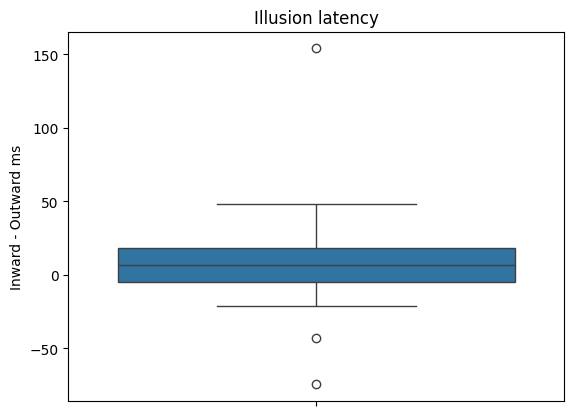

In [7]:
# Summary statistics for the saccade latency
illusLatency_df = filtered_summary_df.groupby(['condition', 'deepeye_id'])[['SaccLat']].mean().reset_index()

# Pivot the DataFrame to have conditions as columns
illusLatency_df = illusLatency_df.pivot(index='deepeye_id', columns='condition', values='SaccLat').reset_index()
illusLatency_df['IllusionLatencyDiff'] = illusLatency_df.arrowHeadsInward - illusLatency_df.arrowHeadsOutward
print(illusLatency_df)

# Plot the illusion latency
plt.figure()
plt.title('Illusion latency')
plt.ylabel('Inward - Outward ms')
sns.boxplot(illusLatency_df.IllusionLatencyDiff)

# T-test
from scipy.stats import ttest_rel
t, p = ttest_rel(illusLatency_df.arrowHeadsInward, illusLatency_df.arrowHeadsOutward)
print(f'T-test: t={t}, p={p}')
print(f'Mean Illusion Latency Inward: {illusLatency_df.arrowHeadsInward.mean()}')
print(f'Mean Illusion Latency Outward: {illusLatency_df.arrowHeadsOutward.mean()}')
print(f'Mean Illusion Latency Diff: {illusLatency_df.IllusionLatencyDiff.mean()}')
print(f'Number of participants: {illusLatency_df.shape[0]}')


### Saccade Latency For all subjects together, for outward and inward arrows

Mean outward latency: 217.25471697974945
Mean inward latency: 222.74689054747674


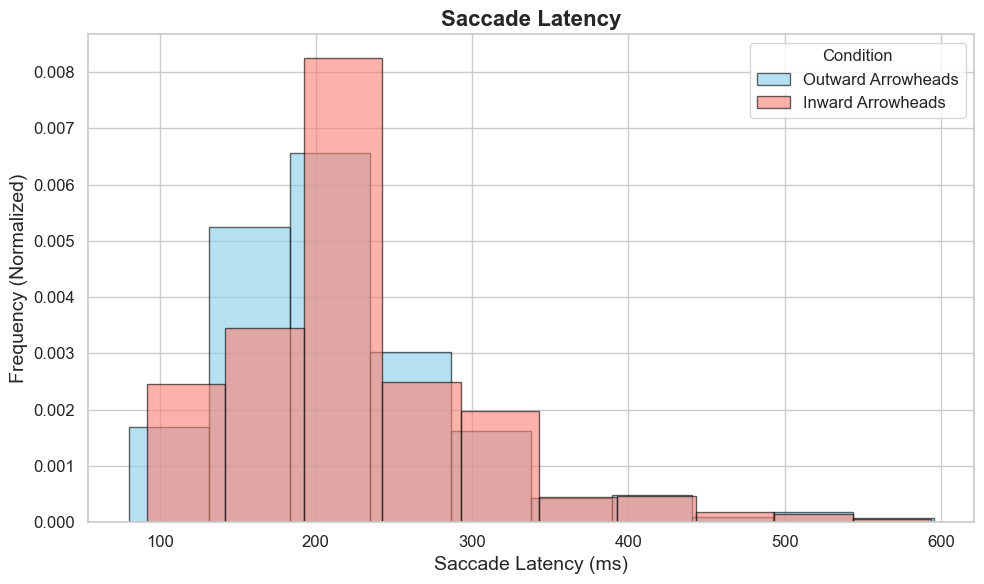

In [8]:
# Plot histograms with normalization
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.title('Saccade Latency', fontsize=16, fontweight='bold')

outward = filtered_summary_df.SaccLat[summary_df.condition == 'arrowHeadsOutward']
inward = filtered_summary_df.SaccLat[summary_df.condition == 'arrowHeadsInward']

print(f'Mean outward latency: {outward.mean()}')
print(f'Mean inward latency: {inward.mean()}')

plt.hist(outward,  alpha=0.6, bins=10, label='Outward Arrowheads', density=True, color='skyblue', edgecolor='black')
plt.hist(inward,  alpha=0.6, bins=10, label='Inward Arrowheads', density=True, color='salmon', edgecolor='black')

plt.legend(title='Condition', fontsize=12)
plt.xlabel('Saccade Latency (ms)', fontsize=14)
plt.ylabel('Frequency (Normalized)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

### Load combined dataframe, filter out trials with bad saccades, normalize to the right, plot raw and fixations for all trials for each participant

### Plot 1D and 2D plots for every participant

In [9]:
# # Merge the summary data with the original data in order to filter out the rejected trials
# merged_df = pd.merge(output_df, summary_df[['deepeye_id', 'trialNr']], on=['deepeye_id', 'trialNr'], how='inner')

# # Loop through each participant
# for name, pp in merged_df.groupby('deepeye_id'):

#     # Intialize 1D and 2D plots
#     fig1_h, ax1 = plt.subplots(figsize=(10, 6)) # 1D plot
#     fig2_h, ax2 = plt.subplots(figsize=(10, 6)) # 2D plot
#     ax1.set_title(f'Target right {name}', fontsize=14, fontweight='bold')
#     ax2.set_title(f'Target right {name}', fontsize=14, fontweight='bold')
#     ax1.set_xlabel('Time (ms)', fontsize=12)
#     ax1.set_ylabel('Horizontal eye position (pixels)', fontsize=12)

#     ## Normalize the endpoints to the target on the right ###
#     pp['NormFixXPos'] = pp.apply(lambda row: row.resX - row.FixXPos if row.target == 'left' else row.FixXPos, axis=1)
#     pp['Norm_user_pred_px_x'] = pp.apply(lambda row: row.resX - row.user_pred_px_x if row.target == 'left' else row.user_pred_px_x, axis=1)
#     pp['Norm_targetX'] = pp.apply(lambda row: row.resX - row.targetX if row.target == 'left' else row.targetX, axis=1)
#     pp['NormfixationStimX'] = pp.apply(lambda row: row.resX - row.fixationStimX if row.target == 'left' else row.fixationStimX, axis=1)

#     # Loop through each trial and plot the data
#     for trial_name, trial in pp.groupby('trialNr'):
        
#         # 1D plot
#         t = np.array(trial.sampTime) - np.array(trial.sampTime)[0]
#         raw_h1 = ax1.scatter(t, trial.Norm_user_pred_px_x, c='yellow', alpha=0.7, edgecolors='black', s=50)
#         fix_h1 = ax1.scatter(t, trial.NormFixXPos, c='blue', alpha=0.7, edgecolors='black', s=50)

#         targX_h1, =ax1.plot(t, trial.Norm_targetX, c='green', lw=2, label='Target Position')
#         fixStim_h1, = ax1.plot(t, trial.NormfixationStimX, c='red', lw=2, linestyle='dashed', label='Fixation Point Position')
        
#         # 2D plot
#         raw_h2 = ax2.scatter(trial.Norm_user_pred_px_x, trial.user_pred_px_y, c='yellow', alpha=0.7, edgecolors='black')    
#         fix_h2 = ax2.scatter(trial.NormFixXPos, trial.FixYPos, c='blue', alpha=0.7, edgecolors='black')
        
#         # plot target and fixation cirle
#         fixStim_h2 = ax2.scatter(trial.NormfixationStimX, trial.fixationStimY, c='red')
#         targX_h2 = ax2.scatter(trial.Norm_targetX, trial.fixationStimY, c='green')

#         # plot target and fixation vertical lines
#         ax2.plot(np.ones(trial.resY.iloc[0].astype('int')) * trial.NormfixationStimX.iloc[0], np.arange(trial.resY.iloc[0]), c='red', lw=1, linestyle='dashed')
#         ax2.plot(np.ones(trial.resY.iloc[0].astype('int')) * trial.Norm_targetX.iloc[0], np.arange(trial.resY.iloc[0]), c='green', lw=1, linestyle='dashed')
        
#         ax2.set_xlim((0, trial.resX.iloc[0]))
#         ax2.set_ylim((trial.resY.iloc[0]), 0)             
               
        
#     # Adjust legend outside plot area and increase font size
#     ax1.legend((raw_h1, fix_h1, fixStim_h1, targX_h1), ('Raw Samples', 'Fixations', 'Fixation Point', 'Target'), loc='upper right', fontsize=10)
#     ax2.legend((raw_h2, fix_h2, fixStim_h2, targX_h2), ('Raw samples', 'Fixations', 'Fixation Point','Target'), loc='upper right', scatterpoints=1, fontsize=10)
       
#     fig1_h.tight_layout()
#     fig2_h.tight_layout() 


In [10]:
# path = r'C:/Users/aby600/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_MullerLyer/MullerLyer_online/complete/data/2024_11_20_14_07_16/2024_11_20_14_07_16_record.csv'

# df = pd.read_csv(path, on_bad_lines='skip')

# a = extract_fixations(df, path)

